# Abscopal hotspot comparison: RT primary vs RT secondary vs no-RT secondary

Compares **spatial pathway hotspots** (Getis-Ord Gi\*) and **CD8 / NK localization**
across three groups, to test whether irradiating the primary tumor reorganizes the
**secondary (abscopal)** tumor.

| Group | Tissues | n | Meaning |
|---|---|---|---|
| **A** RT primary (irradiated)   | `RTCyPSCA_1_*` | 4 | directly irradiated |
| **B** RT secondary (abscopal)   | `RTCyPSCA_2_*` | 2 | contralateral, not irradiated |
| **C** no-RT secondary (control) | `CyPSCA_2_*`   | 4 | secondary, no radiation |

**Key contrasts:** A vs B (abscopal within RT) and **B vs C** (does irradiating the
primary reorganize the secondary vs an unirradiated secondary — the cleanest test).

**Caveat that shapes everything:** the Gi\* hotspot fraction is *relative within each
tissue* (spatial patchiness), **not** an activity level. So every comparison reports a
**level** metric (mean pathway score) alongside the **organization** metrics
(hotspot %, components, Moran's I).

The Gi\* / enrichment functions are **defined inline in the next cell** (kept in sync with
`gistar_utils.py`), because the Jupyter kernel runs on the HPC node while the notebook lives
on the local Mac — so a file-based `import` of the module is not reachable from the kernel.

In [9]:
import re
import sys
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import scanpy as sc
import squidpy as sq
import spatialdata as spd
import statsmodels.formula.api as smf

from scipy.stats import norm, mannwhitneyu
from scipy.sparse.csgraph import connected_components
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests

try:
    from spatialdata.transformations import get_transformation
except Exception:
    get_transformation = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

# =============================================================================
# Gi* utilities — INLINED so this notebook is fully self-contained.
#
# Why inline instead of `import gistar_utils`: the Jupyter kernel runs on the HPC
# node, but this notebook and gistar_utils.py live on the local Mac, which the
# cluster kernel cannot see. Notebook *cell code* is shipped to the kernel and runs
# there, so defining the functions here sidesteps the missing-file problem.
# These are the same as gistar_utils.py — keep them in sync if you edit one.
# =============================================================================
def get_tissue_scale_to_hires(sdata, tissue_name,
                              coordinate_system="downscale_to_hires",
                              shapes_suffix="_cell_boundaries"):
    shapes_key = f"{tissue_name}{shapes_suffix}"
    if get_transformation is None:
        print("WARNING: spatialdata not available. Using scale=1.")
        return 1.0
    if shapes_key not in sdata.shapes:
        print(f"WARNING: {shapes_key} not found in sdata.shapes. Using scale=1.")
        return 1.0
    try:
        shapes_tf = get_transformation(sdata.shapes[shapes_key], get_all=True)[coordinate_system]
        return float(shapes_tf.scale[0])
    except Exception as e:
        print(f"WARNING: Could not get hires scale for {tissue_name}. Using scale=1. Error: {e}")
        return 1.0


def get_tissue_coords_um(adata, sdata, tissue_name, tissue_col,
                         microns_per_pixel, apply_hires_scale=True):
    tissue_mask = adata.obs[tissue_col].astype(str).eq(str(tissue_name)).values
    coords = np.asarray(adata.obsm["spatial"][tissue_mask], dtype=float)
    scale_to_hires = 1.0
    if apply_hires_scale:
        scale_to_hires = get_tissue_scale_to_hires(sdata, tissue_name)
        coords = coords * scale_to_hires
    coords_um = coords * microns_per_pixel
    return tissue_mask, coords_um, scale_to_hires


def calc_getis_ord_gi_star(coords_um, values, k=50):
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n < k + 2:
        raise ValueError(f"Not enough cells for k={k}: n={n}")
    if np.nanstd(values) == 0:
        return np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan)
    n_neighbors = min(k + 1, n)
    nn = NearestNeighbors(n_neighbors=n_neighbors, algorithm="auto")
    nn.fit(coords_um)
    _, idx = nn.kneighbors(coords_um)
    local_sum = values[idx].sum(axis=1)
    xbar = values.mean()
    s = values.std(ddof=0)
    sum_w = idx.shape[1]
    sum_w2 = sum_w  # binary weights: w_ij^2 == w_ij
    denom = s * np.sqrt((n * sum_w2 - sum_w**2) / (n - 1))
    z = (local_sum - xbar * sum_w) / denom
    q_hot = multipletests(norm.sf(z), method="fdr_bh")[1]
    q_cold = multipletests(norm.cdf(z), method="fdr_bh")[1]
    return z, q_hot, q_cold


def label_hotspot_components(coords_um, hotspot_mask, radius_um=50, min_cells=10):
    labels_full = np.full(len(hotspot_mask), -1, dtype=int)
    if hotspot_mask.sum() < min_cells:
        return labels_full
    hot_coords = coords_um[hotspot_mask]
    nn = NearestNeighbors(radius=radius_um)
    nn.fit(hot_coords)
    graph = nn.radius_neighbors_graph(hot_coords, mode="connectivity")
    _, component_labels = connected_components(graph, directed=False, return_labels=True)
    sizes = pd.Series(component_labels).value_counts().to_dict()
    kept = np.array([lab if sizes.get(lab, 0) >= min_cells else -1 for lab in component_labels])
    labels_full[hotspot_mask] = kept
    return labels_full


def hotspot_celltype_enrichment(coords_um, hotspot_mask, celltype_mask,
                                radius_um=50, n_perm=1000, rng=None):
    coords_um = np.asarray(coords_um, dtype=float)
    hotspot_mask = np.asarray(hotspot_mask, dtype=bool)
    celltype_mask = np.asarray(celltype_mask, dtype=bool)
    n = len(hotspot_mask)
    rng = np.random.default_rng(rng)
    result = {"n_hotspot": int(hotspot_mask.sum()), "n_near": 0,
              "n_celltype": int(celltype_mask.sum()), "obs_frac": np.nan,
              "baseline_frac": np.nan, "log2_enrich": np.nan, "emp_p": np.nan,
              "z": np.nan, "null_mean": np.nan, "null_std": np.nan}
    baseline = celltype_mask.mean() if n else np.nan
    result["baseline_frac"] = float(baseline) if np.isfinite(baseline) else np.nan
    n_ct = int(celltype_mask.sum())
    if hotspot_mask.sum() == 0 or n_ct == 0:
        return result
    # near-zone: any cell whose nearest hotspot cell is within radius_um
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(coords_um[hotspot_mask])
    nearest_hot_dist, _ = nn.kneighbors(coords_um)
    near_mask = nearest_hot_dist.ravel() <= radius_um
    n_near = int(near_mask.sum())
    result["n_near"] = n_near
    if n_near == 0:
        return result
    obs_frac = float(celltype_mask[near_mask].mean())
    result["obs_frac"] = obs_frac
    result["log2_enrich"] = float(np.log2(obs_frac / baseline)) if obs_frac > 0 else -np.inf
    # label-permutation null, sampled via hypergeometric for speed
    null_counts = rng.hypergeometric(ngood=n_ct, nbad=n - n_ct, nsample=n_near, size=n_perm)
    null_fracs = null_counts / n_near
    null_mean = float(null_fracs.mean())
    null_std = float(null_fracs.std(ddof=1))
    result["null_mean"] = null_mean
    result["null_std"] = null_std
    result["z"] = float((obs_frac - null_mean) / null_std) if null_std > 0 else np.nan
    diff_obs = abs(obs_frac - null_mean)
    result["emp_p"] = float((np.sum(np.abs(null_fracs - null_mean) >= diff_obs) + 1) / (n_perm + 1))
    return result


def cliffs_delta(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    diff = np.sign(a[:, None] - b[None, :])
    return float(diff.sum() / (len(a) * len(b)))


# Namespace so the rest of the notebook keeps calling gu.<func>(...) unchanged.
gu = SimpleNamespace(
    get_tissue_scale_to_hires=get_tissue_scale_to_hires,
    get_tissue_coords_um=get_tissue_coords_um,
    calc_getis_ord_gi_star=calc_getis_ord_gi_star,
    label_hotspot_components=label_hotspot_components,
    hotspot_celltype_enrichment=hotspot_celltype_enrichment,
    cliffs_delta=cliffs_delta,
)
print("Gi* utilities defined inline (gu namespace ready).")

Gi* utilities defined inline (gu namespace ready).


## 1. Configuration

In [10]:
Gemini_proj_dir = Path("/coh_labs/yunroseli/Jona/CAR-T")

zarr_file   = Gemini_proj_dir / "data/zarr/fullDataset/processing_Zarr/1_C2l_annotated_CC"
pathway_dir = Gemini_proj_dir / "data/references/pathways"
out_dir     = Gemini_proj_dir / "results/hotspot_abscopal_comparison"
fig_dir     = out_dir / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

gmt_files = {
    "hallmark": pathway_dir / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": pathway_dir / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp":    pathway_dir / "m5.go.bp.v2026.1.Mm.symbols.gmt",
    "curated":  pathway_dir / "m2.cp.v2026.1.Mm.symbols.gmt",
}

# --- obs columns ---
TISSUE_COL    = "tissue"
CELL_TYPE_COL = "c2l_permissive"
CONDITION_COL = "treatment"

# --- coordinate conversion ---
MICRONS_PER_PIXEL = 0.34
APPLY_HIRES_SCALE = True

# --- Gi* parameters (match Getis_Ord_Gi_star_test.ipynb) ---
K_GI                        = 50
ALPHA                       = 0.05
MIN_CELLS                   = 100
HOTSPOT_COMPONENT_RADIUS_UM = 50
MIN_HOTSPOT_COMPONENT_CELLS = 10

# --- comparison parameters ---
ENRICH_RADIUS_UM     = 50      # near-hotspot zone for CD8/NK enrichment
N_PERM               = 1000    # permutation null draws
MORAN_N_NEIGHS       = 6       # squidpy spatial graph for Moran's I
SUBSAMPLE_PER_TISSUE = 4000    # cap for the cell-level mixed model
CELLTYPES_OF_INTEREST = ["CD8_T", "NK"]

# Convenience wrapper so we don't repeat config args everywhere.
def coords_um_for(tissue_name):
    return gu.get_tissue_coords_um(
        adata, sdata, tissue_name,
        tissue_col=TISSUE_COL,
        microns_per_pixel=MICRONS_PER_PIXEL,
        apply_hires_scale=APPLY_HIRES_SCALE,
    )

print("config ready ->", out_dir)

config ready -> /coh_labs/yunroseli/Jona/CAR-T/results/hotspot_abscopal_comparison


## 2. Load data

In [11]:
sdata = spd.read_zarr(zarr_file)
adata = sdata.tables["segmentation_counts"]
print(adata)
print("\nTissues in object:", sorted(adata.obs[TISSUE_COL].astype(str).unique()))

AnnData object with n_obs × n_vars = 2088557 × 19059
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'c2l_argmax', 'c2l_permissive', 'c2l_strict', 'c2l_runnerup', 'c2l_consolidated', 'treatment', '_scvi_batch', '_scvi_labels', 'X_cc_01', 'X_cc_1', 'X_cc_012', 'X_cc_2', 'X_cc_0'
    uns: '_scvi_uuid', 'spatial_neighbors', 'spatialdata_attrs', 'condition_colors', 'normalization', '_scvi_manager_uuid', 'log1p'
    obsm: 'c2l_q95', 'X_cc_1', 'X_cc_01', 'spatial', 'X_scVI', 'c2l_q05', 'c2l_means', 'X_cc_2', 'X_cc_0', 'X_cc_012'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'

Tissues in object: ['CyPSCA_1_1', 'CyPSCA_1_2', 'CyPSCA_1_3', 'CyPSCA_1_4', 'CyPSCA_2_1', 'CyPSCA_2_2', 'CyPSCA_2_3', 'CyPSCA_2_4', 'CyT72_1_2', 'CyT72_1_4', 'CyT72_2_3', 'CyT72_2_4', 'NoTx_1_1', 'NoTx_1_2', 'NoTx_1_3', 'NoTx_1_4', 'NoTx_2_1', 'NoTx_2_2', 'NoTx_2_3', 'NoTx_2_4', 'RTCyPSCA_1_2', 'RTCyPSCA_1_3', 'RTCyPSCA_1_4', 'RTC

In [12]:
# --- Read and parse GMT files (same logic as the original notebook) ---
def read_gmt(gmt_path):
    gene_sets = {}
    with open(gmt_path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            gene_sets[parts[0]] = parts[2:]
    return gene_sets

all_gene_sets = {}
for collection, path in gmt_files.items():
    all_gene_sets.update(read_gmt(path))
print(f"Total gene sets loaded: {len(all_gene_sets):,}")

Total gene sets loaded: 9,618


## 3. Pathway panel (base + additions)

`debris_to_presentation_primary_panel` is the existing panel. `panel_additions` fills the
gaps that this abscopal hypothesis hinges on: **MHC-I / CD8 axis**, **type-I IFN +
cGAS-STING** (the canonical radiation->abscopal driver), **effector cytotoxicity +
lymphocyte chemotaxis**, and **DC antigen presentation**. All were confirmed present in the
GMTs; the scorer still skips any set with <5 matched genes (flagged below).

In [13]:
debris_to_presentation_primary_panel = {
    "GranzymeDeath_GO":          "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY",
    "Phagocytosis_GO":           "GOBP_PHAGOCYTOSIS",
    "EngulfmentOfApoptoticCell_GO": "GOBP_ENGULFMENT_OF_APOPTOTIC_CELL",
    "LysosomeOrganization_GO":   "GOBP_LYSOSOME_ORGANIZATION",
    "AntigenPresentation_GO":    "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION",
    "MHCII_ExogenousPeptide_GO": "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_II",
    "CrossPresentation_Reactome":"REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION",
    "IFN_gamma":                 "HALLMARK_INTERFERON_GAMMA_RESPONSE",
}

panel_additions = {
    # MHC-I / CD8 axis
    "MHCI_PeptideAntigen_GO":   "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_I",
    "MHCI_Loading_Reactome":    "REACTOME_ANTIGEN_PRESENTATION_FOLDING_ASSEMBLY_AND_PEPTIDE_LOADING_OF_CLASS_I_MHC",
    "ERphagosome_Reactome":     "REACTOME_ER_PHAGOSOME_PATHWAY",
    # Type I IFN + cGAS-STING (radiation -> abscopal mechanism)
    "IFN_alpha":                "HALLMARK_INTERFERON_ALPHA_RESPONSE",
    "TypeI_IFN_Signaling_Reactome": "REACTOME_INTERFERON_ALPHA_BETA_SIGNALING",
    "cGAS_STING_GO":            "GOBP_CGAS_STING_SIGNALING_PATHWAY",
    # Effector + recruitment
    "TcellCytotoxicity_GO":     "GOBP_T_CELL_MEDIATED_CYTOTOXICITY",
    "LeukocyteCytotoxicity_GO": "GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY",
    "LymphocyteChemotaxis_GO":  "GOBP_LYMPHOCYTE_CHEMOTAXIS",
    # DC cross-priming
    "DC_AntigenPresentation_GO":"GOBP_DENDRITIC_CELL_ANTIGEN_PROCESSING_AND_PRESENTATION",
}

COMBINED_PANEL = {**debris_to_presentation_primary_panel, **panel_additions}

# Confirm every gene set exists in the loaded GMTs.
panel_check = pd.DataFrame([
    {"short_name": k, "gene_set": v,
     "found": v in all_gene_sets,
     "n_genes_in_set": len(all_gene_sets.get(v, [])),
     "is_addition": k in panel_additions}
    for k, v in COMBINED_PANEL.items()
])
display(panel_check)
missing = panel_check.loc[~panel_check["found"], "short_name"].tolist()
if missing:
    print("WARNING: gene sets not found in GMTs:", missing)

,short_name,gene_set,found,n_genes_in_set,is_addition
0,GranzymeDeath_GO,GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_S...,True,11,False
1,Phagocytosis_GO,GOBP_PHAGOCYTOSIS,True,248,False
2,EngulfmentOfApoptoticCell_GO,GOBP_ENGULFMENT_OF_APOPTOTIC_CELL,True,12,False
3,LysosomeOrganization_GO,GOBP_LYSOSOME_ORGANIZATION,False,0,False
4,AntigenPresentation_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION,True,133,False
5,MHCII_ExogenousPeptide_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,True,20,False
6,CrossPresentation_Reactome,REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION,True,68,False
7,IFN_gamma,HALLMARK_INTERFERON_GAMMA_RESPONSE,True,188,False
8,MHCI_PeptideAntigen_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PE...,True,58,True
9,MHCI_Loading_Reactome,REACTOME_ANTIGEN_PRESENTATION_FOLDING_ASSEMBLY...,True,33,True


## 4. Score pathways (coverage check)

In [14]:
available_genes = set(adata.var_names.astype(str))
score_records = []

for short_name, gene_set_name in COMBINED_PANEL.items():
    pathway_genes = all_gene_sets.get(gene_set_name, [])
    matched = [g for g in pathway_genes if g in available_genes]
    score_col = f"{short_name}_score"
    status = "scored"
    if len(matched) < 5:
        status = "SKIPPED (<5 genes)"
    else:
        sc.tl.score_genes(adata, gene_list=matched, score_name=score_col, use_raw=False)
    score_records.append({
        "short_name": short_name, "score_col": score_col,
        "n_matched": len(matched), "n_in_set": len(pathway_genes),
        "is_addition": short_name in panel_additions, "status": status,
    })

score_coverage = pd.DataFrame(score_records)
display(score_coverage.sort_values(["is_addition", "status", "short_name"]))

# score_cols = every panel pathway that was actually scored and is in obs
score_cols = [
    f"{r.short_name}_score" for r in score_coverage.itertuples()
    if r.status == "scored" and f"{r.short_name}_score" in adata.obs.columns
]
print(f"\n{len(score_cols)} pathway score columns available:")
print(score_cols)
if (score_coverage["status"] != "scored").any():
    print("\nNOTE skipped (likely targeted-panel gene coverage):",
          score_coverage.loc[score_coverage.status != "scored", "short_name"].tolist())

,short_name,score_col,n_matched,n_in_set,is_addition,status
3,LysosomeOrganization_GO,LysosomeOrganization_GO_score,0,0,False,SKIPPED (<5 genes)
4,AntigenPresentation_GO,AntigenPresentation_GO_score,117,133,False,scored
6,CrossPresentation_Reactome,CrossPresentation_Reactome_score,65,68,False,scored
2,EngulfmentOfApoptoticCell_GO,EngulfmentOfApoptoticCell_GO_score,12,12,False,scored
0,GranzymeDeath_GO,GranzymeDeath_GO_score,10,11,False,scored
7,IFN_gamma,IFN_gamma_score,180,188,False,scored
5,MHCII_ExogenousPeptide_GO,MHCII_ExogenousPeptide_GO_score,19,20,False,scored
1,Phagocytosis_GO,Phagocytosis_GO_score,241,248,False,scored
17,DC_AntigenPresentation_GO,DC_AntigenPresentation_GO_score,17,18,True,scored
10,ERphagosome_Reactome,ERphagosome_Reactome_score,33,36,True,scored



17 pathway score columns available:
['GranzymeDeath_GO_score', 'Phagocytosis_GO_score', 'EngulfmentOfApoptoticCell_GO_score', 'AntigenPresentation_GO_score', 'MHCII_ExogenousPeptide_GO_score', 'CrossPresentation_Reactome_score', 'IFN_gamma_score', 'MHCI_PeptideAntigen_GO_score', 'MHCI_Loading_Reactome_score', 'ERphagosome_Reactome_score', 'IFN_alpha_score', 'TypeI_IFN_Signaling_Reactome_score', 'cGAS_STING_GO_score', 'TcellCytotoxicity_GO_score', 'LeukocyteCytotoxicity_GO_score', 'LymphocyteChemotaxis_GO_score', 'DC_AntigenPresentation_GO_score']

NOTE skipped (likely targeted-panel gene coverage): ['LysosomeOrganization_GO']


## 5. Tissue groups

Groups are parsed straight from the tissue string `COND_loc_rep` (robust; does not depend on
which obs metadata columns exist). Group **B has only n=2** — the cell below flags any
additional `RTCyPSCA_2_*` / `CyPSCA_2_*` replicates present in the data so you can add them.

In [15]:
TISSUES = [
    # A: RT primary (irradiated)
    "RTCyPSCA_1_2", "RTCyPSCA_1_3", "RTCyPSCA_1_4", "RTCyPSCA_1_5",
    # B: RT secondary (abscopal)
    "RTCyPSCA_2_3", "RTCyPSCA_2_4",
    # C: no-RT secondary (control)
    "CyPSCA_2_1", "CyPSCA_2_2", "CyPSCA_2_3", "CyPSCA_2_4",
]

GROUP_ORDER  = ["A_RT_primary", "B_RT_secondary", "C_noRT_secondary"]
GROUP_LABELS = {
    "A_RT_primary":     "A: RT primary",
    "B_RT_secondary":   "B: RT secondary (abscopal)",
    "C_noRT_secondary": "C: no-RT secondary",
}

def parse_tissue(t):
    m = re.match(r"^(.*)_(\d+)_(\d+)$", str(t))
    if not m:
        return None, None, None
    return m.group(1), int(m.group(2)), int(m.group(3))

def assign_group(t):
    cond, loc, rep = parse_tissue(t)
    if cond == "RTCyPSCA" and loc == 1: return "A_RT_primary"
    if cond == "RTCyPSCA" and loc == 2: return "B_RT_secondary"
    if cond == "CyPSCA"   and loc == 2: return "C_noRT_secondary"
    return "other"

tissues_in_data = set(adata.obs[TISSUE_COL].astype(str).unique())

# Which requested tissues are actually present?
missing_tissues = [t for t in TISSUES if t not in tissues_in_data]
if missing_tissues:
    print("WARNING: requested tissues NOT in data:", missing_tissues)
TISSUES_PRESENT = [t for t in TISSUES if t in tissues_in_data]

# Any extra replicates in the data that match our groups but were not listed?
extra = sorted(t for t in tissues_in_data
               if assign_group(t) in GROUP_ORDER and t not in TISSUES)
if extra:
    print("NOTE: additional matching replicates present in data (not in TISSUES):", extra)
    print("      -> add them to TISSUES above if you want them included.")

tissue_meta = pd.DataFrame({"tissue": TISSUES_PRESENT})
tissue_meta[["condition", "tumor_loc", "rep"]] = tissue_meta["tissue"].apply(
    lambda t: pd.Series(parse_tissue(t)))
tissue_meta["group"] = tissue_meta["tissue"].map(assign_group)
tissue_to_group = dict(zip(tissue_meta["tissue"], tissue_meta["group"]))

print("\nGroup sizes:")
print(tissue_meta.groupby("group")["tissue"].agg(list))
display(tissue_meta)


Group sizes:
group
A_RT_primary        [RTCyPSCA_1_2, RTCyPSCA_1_3, RTCyPSCA_1_4, RTC...
B_RT_secondary                           [RTCyPSCA_2_3, RTCyPSCA_2_4]
C_noRT_secondary     [CyPSCA_2_1, CyPSCA_2_2, CyPSCA_2_3, CyPSCA_2_4]
Name: tissue, dtype: object


,tissue,condition,tumor_loc,rep,group
0,RTCyPSCA_1_2,RTCyPSCA,1,2,A_RT_primary
1,RTCyPSCA_1_3,RTCyPSCA,1,3,A_RT_primary
2,RTCyPSCA_1_4,RTCyPSCA,1,4,A_RT_primary
3,RTCyPSCA_1_5,RTCyPSCA,1,5,A_RT_primary
4,RTCyPSCA_2_3,RTCyPSCA,2,3,B_RT_secondary
5,RTCyPSCA_2_4,RTCyPSCA,2,4,B_RT_secondary
6,CyPSCA_2_1,CyPSCA,2,1,C_noRT_secondary
7,CyPSCA_2_2,CyPSCA,2,2,C_noRT_secondary
8,CyPSCA_2_3,CyPSCA,2,3,C_noRT_secondary
9,CyPSCA_2_4,CyPSCA,2,4,C_noRT_secondary


## 6. Coordinate sanity check

In [16]:
t0 = TISSUES_PRESENT[0]
m0, c0, s0 = coords_um_for(t0)
print(f"1 H&E pixel = {MICRONS_PER_PIXEL} um | tissue {t0} | cells {m0.sum():,} | scale {s0:.6f}")
print(f"x range {c0[:,0].min():.0f}..{c0[:,0].max():.0f} um (width {np.ptp(c0[:,0]):.0f})")
print(f"y range {c0[:,1].min():.0f}..{c0[:,1].max():.0f} um (height {np.ptp(c0[:,1]):.0f})")

1 H&E pixel = 0.34 um | tissue RTCyPSCA_1_2 | cells 28,637 | scale 0.234119
x range 915..1659 um (width 744)
y range 1051..1656 um (height 605)


## 7. Engine: per-tissue x pathway metrics

For each tissue x pathway, run Gi\* and record both the **level** metric (mean/median
pathway score) and **organization** metrics (hotspot %, components, median Gi-z, Moran's I).
Hotspot labels are written back to `adata.obs` for the enrichment step.

In [17]:
def moran_for_tissue(tissue_mask, cols, n_neighs=MORAN_N_NEIGHS):
    """Global Moran's I per pathway score within one tissue (squidpy)."""
    out = {c: np.nan for c in cols}
    try:
        sub = adata[tissue_mask].copy()
        valid = [c for c in cols if np.isfinite(sub.obs[c].astype(float)).sum() > 10
                 and sub.obs[c].astype(float).std() > 0]
        if not valid:
            return out
        sq.gr.spatial_neighbors(sub, coord_type="generic", n_neighs=n_neighs)
        sq.gr.spatial_autocorr(sub, mode="moran", genes=valid, attr="obs",
                               n_perms=None, n_jobs=1, seed=0)
        for c, I in sub.uns["moranI"]["I"].items():
            out[c] = float(I)
    except Exception as e:
        print(f"    Moran's I failed: {e}")
    return out

# initialize per-pathway hotspot columns
for sc_col in score_cols:
    adata.obs[f"{sc_col}_GiZ"]     = np.nan
    adata.obs[f"{sc_col}_q_hot"]   = np.nan
    adata.obs[f"{sc_col}_hotspot"] = False

metric_rows = []
for tissue_name in TISSUES_PRESENT:
    tissue_mask, coords_um, scale = coords_um_for(tissue_name)
    obs_names = adata.obs_names[tissue_mask]
    n_cells = int(tissue_mask.sum())
    if n_cells < MIN_CELLS:
        print(f"Skip {tissue_name}: {n_cells} cells")
        continue
    cond, loc, rep = parse_tissue(tissue_name)
    grp = tissue_to_group[tissue_name]
    print(f"\n{tissue_name} | {grp} | n={n_cells:,}")

    moran = moran_for_tissue(tissue_mask, score_cols)

    for sc_col in score_cols:
        values = adata.obs.loc[tissue_mask, sc_col].astype(float).values
        good = np.isfinite(values)
        if good.sum() < MIN_CELLS:
            continue
        z, q_hot, q_cold = gu.calc_getis_ord_gi_star(coords_um[good], values[good], k=K_GI)
        hot  = (z > 0) & (q_hot < ALPHA)
        cold = (z < 0) & (q_cold < ALPHA)
        comp = gu.label_hotspot_components(
            coords_um[good], hot,
            radius_um=HOTSPOT_COMPONENT_RADIUS_UM,
            min_cells=MIN_HOTSPOT_COMPONENT_CELLS)
        n_comp = len(set(comp[comp >= 0]))

        sub_names = obs_names[good]
        adata.obs.loc[sub_names, f"{sc_col}_GiZ"]     = z
        adata.obs.loc[sub_names, f"{sc_col}_q_hot"]   = q_hot
        adata.obs.loc[sub_names, f"{sc_col}_hotspot"] = hot

        metric_rows.append({
            "tissue": tissue_name, "group": grp, "condition": cond,
            "tumor_loc": loc, "rep": rep, "pathway": sc_col, "n_cells": n_cells,
            "mean_score":   float(np.nanmean(values)),
            "median_score": float(np.nanmedian(values)),
            "moranI":       moran.get(sc_col, np.nan),
            "pct_hotspot":  float(hot.mean() * 100),
            "pct_coldspot": float(cold.mean() * 100),
            "n_components": int(n_comp),
            "median_GiZ_hot": float(np.nanmedian(z[hot])) if hot.sum() else np.nan,
        })
    print(f"  done {len([r for r in metric_rows if r['tissue']==tissue_name])} pathways")

metrics_long = pd.DataFrame(metric_rows)
metrics_long["group"] = pd.Categorical(metrics_long["group"], categories=GROUP_ORDER, ordered=True)
print("\nmetrics_long:", metrics_long.shape)
display(metrics_long.head())


RTCyPSCA_1_2 | A_RT_primary | n=28,637
  done 17 pathways

RTCyPSCA_1_3 | A_RT_primary | n=57,620
  done 17 pathways

RTCyPSCA_1_4 | A_RT_primary | n=69,639
  done 17 pathways

RTCyPSCA_1_5 | A_RT_primary | n=35,860
  done 17 pathways

RTCyPSCA_2_3 | B_RT_secondary | n=112,486
  done 17 pathways

RTCyPSCA_2_4 | B_RT_secondary | n=65,157
  done 17 pathways

CyPSCA_2_1 | C_noRT_secondary | n=86,108
  done 17 pathways

CyPSCA_2_2 | C_noRT_secondary | n=61,384
  done 17 pathways

CyPSCA_2_3 | C_noRT_secondary | n=67,945
  done 17 pathways

CyPSCA_2_4 | C_noRT_secondary | n=54,121
  done 17 pathways

metrics_long: (170, 14)


,tissue,group,condition,tumor_loc,rep,pathway,n_cells,mean_score,median_score,moranI,pct_hotspot,pct_coldspot,n_components,median_GiZ_hot
0,RTCyPSCA_1_2,A_RT_primary,RTCyPSCA,1,2,GranzymeDeath_GO_score,28637,0.129394,0.089136,0.281946,27.813668,26.766072,1,3.913690
1,RTCyPSCA_1_2,A_RT_primary,RTCyPSCA,1,2,Phagocytosis_GO_score,28637,0.130602,0.129949,0.387550,33.683696,24.946747,3,3.661977
2,RTCyPSCA_1_2,A_RT_primary,RTCyPSCA,1,2,EngulfmentOfApoptoticCell_GO_score,28637,-0.021724,-0.060334,0.199152,20.354786,24.496281,3,4.449886
3,RTCyPSCA_1_2,A_RT_primary,RTCyPSCA,1,2,AntigenPresentation_GO_score,28637,0.261179,0.261206,0.628644,41.907323,34.717324,1,4.743088
4,RTCyPSCA_1_2,A_RT_primary,RTCyPSCA,1,2,MHCII_ExogenousPeptide_GO_score,28637,0.741847,0.750045,0.648846,39.574676,34.053846,2,4.923156


In [18]:
# Quick group means per pathway (sanity view)
display(
    metrics_long
    .groupby(["pathway", "group"], observed=True)[["mean_score", "pct_hotspot", "moranI"]]
    .mean()
    .round(3)
    .unstack("group")
)

mean_score                                  pct_hotspot                                       moranI                                
group                              A_RT_primary B_RT_secondary C_noRT_secondary A_RT_primary B_RT_secondary C_noRT_secondary A_RT_primary B_RT_secondary C_noRT_secondary
pathway                                                                                                                                                                  
AntigenPresentation_GO_score              0.228          0.187            0.312       36.117         30.338           33.776        0.598          0.638            0.494
CrossPresentation_Reactome_score          0.213          0.202            0.217       23.743         18.785           22.736        0.239          0.220            0.231
DC_AntigenPresentation_GO_score           0.206          0.135            0.356       32.851         32.283           30.940        0.497          0.539            0.350
ERphagosome_Reactome_score                0.147          0.128            0.171       24.544         21.660           17.075        0.190          0.165            0.138
EngulfmentOfApoptoticCell_GO_score       -0.057         -0.072           -0.046       13.893         20.714           11.441        0.154          0.190            0.101
GranzymeDeath_GO_score                    0.033          0.076            0.217       21.166         24.948           22.033        0.284          0.334            0.260
IFN_alpha_score                           0.227          0.164            0.299       36.645         35.533           33.024        0.608          0.631            0.484
IFN_gamma_score                           0.242          0.182            0.303       37.276         34.677           35.556        0.652          0.675            0.545
LeukocyteCytotoxicity_GO_score            0.069          0.052            0.113       34.013         31.144           31.919        0.514          0.556            0.409
LymphocyteChemotaxis_GO_score             0.131          0.093            0.142       22.495         23.791           19.898        0.218          0.212            0.183
MHCII_ExogenousPeptide_GO_score           0.623          0.509            0.937       36.330         29.436           36.381        0.629          0.676            0.547
MHCI_Loading_Reactome_score               0.166          0.145            0.177       17.105         17.565           11.649        0.131          0.132            0.108
MHCI_PeptideAntigen_GO_score              0.161          0.125            0.231       33.729         31.048           29.318        0.458          0.494            0.339
Phagocytosis_GO_score                     0.123          0.108            0.143       26.064         23.423           24.000        0.309          0.289            0.286
TcellCytotoxicity_GO_score                0.067          0.050            0.119       32.897         31.074           28.904        0.446          0.485            0.320
TypeI_IFN_Signaling_Reactome_score        0.061          0.038            0.080       18.424         16.426           11.734        0.127          0.105            0.087
cGAS_STING_GO_score                       0.057          0.049            0.058       25.302         23.078           10.419        0.180          0.159            0.079

## 7b. Significant-hotspot tables (hot & cold)

Which pathways show statistically significant Gi\* **hotspots** / **coldspots** in each
tissue, using the **BH-FDR** q-values (`q_hot` / `q_cold` < `ALPHA`) already computed per
cell inside `calc_getis_ord_gi_star`. The `%` tables give magnitude (share of cells that
passed FDR); the boolean tables flag tissue×pathway combos with at least
`MIN_SIG_HOTSPOT_CELLS` FDR-significant cells. Because the tissues are large, nearly every
pathway has *some* significant cells — so the **%** is the discriminating view, and the
boolean requires a spatially meaningful minimum.

In [32]:
# Significant-hotspot tables (HOT and COLD), tissue x pathway.
# Significance = Gi* BH-FDR q < ALPHA per cell (q_hot for hot, q_cold for cold),
# already applied in calc_getis_ord_gi_star. metrics_long stores the % of such
# cells per tissue x pathway; n_* is reconstructed from pct * n_cells.
MIN_SIG_HOTSPOT_CELLS = 10   # min FDR-significant cells to flag a hotspot as "present"

ml = metrics_long.copy()
ml["n_hotspot"]  = (ml["pct_hotspot"]  / 100.0 * ml["n_cells"]).round().astype(int)
ml["n_coldspot"] = (ml["pct_coldspot"] / 100.0 * ml["n_cells"]).round().astype(int)

tcols = [t for t in TISSUES_PRESENT if t in set(ml["tissue"])]

def _grid(value_col):
    return ml.pivot_table(index="pathway", columns="tissue", values=value_col).reindex(columns=tcols)

hot_pct   = _grid("pct_hotspot").round(2)
cold_pct  = _grid("pct_coldspot").round(2)
hot_flag  = (_grid("n_hotspot")  >= MIN_SIG_HOTSPOT_CELLS)
cold_flag = (_grid("n_coldspot") >= MIN_SIG_HOTSPOT_CELLS)

print(f"HOT - % of cells in FDR-significant hotspots (q_hot < {ALPHA}), tissue x pathway:")
display(hot_pct)
print(f"\nCOLD - % of cells in FDR-significant coldspots (q_cold < {ALPHA}):")
display(cold_pct)
print(f"\nSignificant HOT present (>= {MIN_SIG_HOTSPOT_CELLS} FDR-significant cells):")
display(hot_flag)
print(f"\nSignificant COLD present (>= {MIN_SIG_HOTSPOT_CELLS} FDR-significant cells):")
display(cold_flag)

print("\n# significant HOT pathways per tissue:")
print(hot_flag.sum(axis=0).to_string())

for name, df in [("hotspot_pct_hot", hot_pct), ("hotspot_pct_cold", cold_pct),
                 ("hotspot_flag_hot", hot_flag), ("hotspot_flag_cold", cold_flag)]:
    df.to_csv(out_dir / f"sig_{name}.csv")
print("\nSaved 4 significant-hotspot tables to:", out_dir)


HOT - % of cells in FDR-significant hotspots (q_hot < 0.05), tissue x pathway:


tissue,RTCyPSCA_1_2,RTCyPSCA_1_3,RTCyPSCA_1_4,RTCyPSCA_1_5,RTCyPSCA_2_3,RTCyPSCA_2_4,CyPSCA_2_1,CyPSCA_2_2,CyPSCA_2_3,CyPSCA_2_4
pathway,,,,,,,,,,
AntigenPresentation_GO_score,41.91,34.91,33.01,34.64,26.29,34.39,33.94,30.40,31.67,39.09
CrossPresentation_Reactome_score,37.20,17.03,22.28,18.46,10.25,27.32,24.23,18.85,28.14,19.73
DC_AntigenPresentation_GO_score,33.39,33.17,32.02,32.82,29.43,35.14,28.32,32.32,27.29,35.83
ERphagosome_Reactome_score,30.24,27.96,14.96,25.01,19.27,24.05,20.82,14.27,7.59,25.62
EngulfmentOfApoptoticCell_GO_score,20.35,18.00,6.16,11.06,17.59,23.84,8.02,16.15,3.70,17.89
GranzymeDeath_GO_score,27.81,24.42,18.04,14.39,25.59,24.30,25.49,21.92,10.60,30.11
IFN_alpha_score,40.80,39.67,28.61,37.50,33.24,37.83,35.34,32.81,21.72,42.22
IFN_gamma_score,42.97,36.98,32.03,37.12,31.35,38.00,36.80,33.83,26.25,45.35
LeukocyteCytotoxicity_GO_score,39.86,33.70,29.41,33.08,26.93,35.36,32.10,28.73,26.83,40.02



COLD - % of cells in FDR-significant coldspots (q_cold < 0.05):


tissue,RTCyPSCA_1_2,RTCyPSCA_1_3,RTCyPSCA_1_4,RTCyPSCA_1_5,RTCyPSCA_2_3,RTCyPSCA_2_4,CyPSCA_2_1,CyPSCA_2_2,CyPSCA_2_3,CyPSCA_2_4
pathway,,,,,,,,,,
AntigenPresentation_GO_score,34.72,41.73,34.16,36.76,41.85,37.47,30.32,29.07,31.54,33.55
CrossPresentation_Reactome_score,26.76,15.50,28.64,17.02,12.51,27.22,20.92,20.36,30.38,15.17
DC_AntigenPresentation_GO_score,31.52,43.51,28.79,35.03,41.27,33.95,28.65,27.74,23.97,32.57
ERphagosome_Reactome_score,30.21,29.06,15.43,24.69,18.16,27.22,20.43,16.55,9.72,21.27
EngulfmentOfApoptoticCell_GO_score,24.50,17.95,6.87,9.49,17.80,27.58,4.22,14.40,0.75,17.36
GranzymeDeath_GO_score,26.77,35.58,17.45,14.05,35.97,29.01,25.66,22.40,5.67,31.13
IFN_alpha_score,36.98,38.56,26.88,34.00,36.57,38.41,35.33,28.62,26.63,28.65
IFN_gamma_score,38.69,39.70,36.03,34.61,41.19,40.59,32.94,29.85,29.39,30.05
LeukocyteCytotoxicity_GO_score,33.98,40.69,31.33,33.73,38.61,35.19,28.90,25.16,28.93,33.12



Significant HOT present (>= 10 FDR-significant cells):


tissue,RTCyPSCA_1_2,RTCyPSCA_1_3,RTCyPSCA_1_4,RTCyPSCA_1_5,RTCyPSCA_2_3,RTCyPSCA_2_4,CyPSCA_2_1,CyPSCA_2_2,CyPSCA_2_3,CyPSCA_2_4
pathway,,,,,,,,,,
AntigenPresentation_GO_score,True,True,True,True,True,True,True,True,True,True
CrossPresentation_Reactome_score,True,True,True,True,True,True,True,True,True,True
DC_AntigenPresentation_GO_score,True,True,True,True,True,True,True,True,True,True
ERphagosome_Reactome_score,True,True,True,True,True,True,True,True,True,True
EngulfmentOfApoptoticCell_GO_score,True,True,True,True,True,True,True,True,True,True
GranzymeDeath_GO_score,True,True,True,True,True,True,True,True,True,True
IFN_alpha_score,True,True,True,True,True,True,True,True,True,True
IFN_gamma_score,True,True,True,True,True,True,True,True,True,True
LeukocyteCytotoxicity_GO_score,True,True,True,True,True,True,True,True,True,True



Significant COLD present (>= 10 FDR-significant cells):


tissue,RTCyPSCA_1_2,RTCyPSCA_1_3,RTCyPSCA_1_4,RTCyPSCA_1_5,RTCyPSCA_2_3,RTCyPSCA_2_4,CyPSCA_2_1,CyPSCA_2_2,CyPSCA_2_3,CyPSCA_2_4
pathway,,,,,,,,,,
AntigenPresentation_GO_score,True,True,True,True,True,True,True,True,True,True
CrossPresentation_Reactome_score,True,True,True,True,True,True,True,True,True,True
DC_AntigenPresentation_GO_score,True,True,True,True,True,True,True,True,True,True
ERphagosome_Reactome_score,True,True,True,True,True,True,True,True,True,True
EngulfmentOfApoptoticCell_GO_score,True,True,True,True,True,True,True,True,True,True
GranzymeDeath_GO_score,True,True,True,True,True,True,True,True,True,True
IFN_alpha_score,True,True,True,True,True,True,True,True,True,True
IFN_gamma_score,True,True,True,True,True,True,True,True,True,True
LeukocyteCytotoxicity_GO_score,True,True,True,True,True,True,True,True,True,True



# significant HOT pathways per tissue:
tissue
RTCyPSCA_1_2    17
RTCyPSCA_1_3    17
RTCyPSCA_1_4    17
RTCyPSCA_1_5    17
RTCyPSCA_2_3    17
RTCyPSCA_2_4    17
CyPSCA_2_1      17
CyPSCA_2_2      17
CyPSCA_2_3      17
CyPSCA_2_4      17

Saved 4 significant-hotspot tables to: /coh_labs/yunroseli/Jona/CAR-T/results/hotspot_abscopal_comparison


### Heatmap of significant-hotspot %

Share of cells per tissue that are **FDR-significant Gi\* hot (red) / cold (blue)** members,
for each pathway. Tissues are grouped A | B | C (white separators); rows are sorted by mean
% so the most spatially-clustered pathways sit on top.

In [ ]:
# Heatmap of the significant-hotspot percentages (hot and cold), tissue x pathway.
def plot_pct_heatmap(pct_df, title, fname, cmap="Reds"):
    df = pct_df.dropna(how="all")
    if df.empty:
        print("nothing to plot for", title)
        return
    df = df.loc[df.mean(axis=1).sort_values(ascending=False).index]   # strongest pathways on top
    data = df.values.astype(float)
    npath, ntiss = data.shape
    vmax = np.nanmax(data)
    vmax = vmax if np.isfinite(vmax) and vmax > 0 else 1.0
    gtag = {"A_RT_primary": "A", "B_RT_secondary": "B", "C_noRT_secondary": "C"}
    groups = [tissue_to_group.get(t, "other") for t in df.columns]

    fig, ax = plt.subplots(figsize=(1.15 * ntiss + 2.5, 0.42 * npath + 2.0))
    im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=0, vmax=vmax)
    ax.set_xticks(range(ntiss))
    ax.set_xticklabels([f"{t}\n[{gtag.get(g, '?')}]" for t, g in zip(df.columns, groups)],
                       rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(npath))
    ax.set_yticklabels(df.index, fontsize=8)
    for i in range(npath):
        for j in range(ntiss):
            v = data[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7,
                        color="white" if v > 0.6 * vmax else "black")
    for k in range(1, ntiss):                          # white separators between groups
        if groups[k] != groups[k - 1]:
            ax.axvline(k - 0.5, color="w", lw=2.5)
    ax.set_title(title, fontsize=11)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("% cells in significant spot", fontsize=8)
    fig.tight_layout()
    fig.savefig(fig_dir / fname, dpi=150, bbox_inches="tight")
    plt.show()

plot_pct_heatmap(hot_pct,  f"HOT: % cells in FDR-significant hotspots (q_hot < {ALPHA})",
                 "sig_hotspot_pct_hot_heatmap.png", cmap="Reds")
plot_pct_heatmap(cold_pct, f"COLD: % cells in FDR-significant coldspots (q_cold < {ALPHA})",
                 "sig_hotspot_pct_cold_heatmap.png", cmap="Blues")


## 8. Q1 — pathway hotspot differences between groups

**Replicate-level (primary).** For each pathway and metric, compare the two key contrasts
**A vs B** and **B vs C** with Mann-Whitney U + Cliff's delta. With n=4/2/4 these p-values are
weak by construction — read them as **trends supported by effect size and per-replicate
consistency**, not significance tests.

In [19]:
METRICS_Q1 = ["mean_score", "pct_hotspot", "n_components", "moranI", "median_GiZ_hot"]
CONTRASTS = [("A_RT_primary", "B_RT_secondary"), ("B_RT_secondary", "C_noRT_secondary")]

def contrast_rows(df, value_col, key_cols):
    rows = []
    for keys, sub in df.groupby(key_cols, observed=True):
        keys = keys if isinstance(keys, tuple) else (keys,)
        rec = dict(zip(key_cols, keys))
        for g1, g2 in CONTRASTS:
            a = sub.loc[sub["group"] == g1, value_col].dropna().values
            b = sub.loc[sub["group"] == g2, value_col].dropna().values
            tag = f"{g1.split('_')[0]}_vs_{g2.split('_')[0]}"
            delta = gu.cliffs_delta(a, b)
            if len(a) >= 1 and len(b) >= 1:
                med_diff = np.median(a) - np.median(b)
            else:
                med_diff = np.nan
            try:
                p = mannwhitneyu(a, b, alternative="two-sided").pvalue if len(a) and len(b) else np.nan
            except ValueError:
                p = np.nan
            rec[f"{tag}__median_diff"] = med_diff
            rec[f"{tag}__cliffs_delta"] = delta
            rec[f"{tag}__mwu_p"] = p
        rows.append(rec)
    return pd.DataFrame(rows)

q1_contrasts = {}
for metric in METRICS_Q1:
    q1_contrasts[metric] = contrast_rows(metrics_long, metric, ["pathway"])

group_contrasts_q1 = pd.concat(
    [df.assign(metric=m) for m, df in q1_contrasts.items()], ignore_index=True)
cols_front = ["metric", "pathway"]
group_contrasts_q1 = group_contrasts_q1[cols_front + [c for c in group_contrasts_q1.columns if c not in cols_front]]
display(group_contrasts_q1.sort_values(["metric", "pathway"]).round(3))

,metric,pathway,A_vs_B__median_diff,A_vs_B__cliffs_delta,A_vs_B__mwu_p,B_vs_C__median_diff,B_vs_C__cliffs_delta,B_vs_C__mwu_p
0,mean_score,AntigenPresentation_GO_score,0.040,0.75,0.267,-0.146,-1.00,0.133
1,mean_score,CrossPresentation_Reactome_score,0.026,0.25,0.800,-0.002,0.00,1.000
2,mean_score,DC_AntigenPresentation_GO_score,0.067,0.75,0.267,-0.232,-1.00,0.133
3,mean_score,ERphagosome_Reactome_score,0.026,0.50,0.533,-0.042,-0.50,0.533
4,mean_score,EngulfmentOfApoptoticCell_GO_score,0.013,0.25,0.800,-0.034,-0.50,0.533
...,...,...,...,...,...,...,...,...
29,pct_hotspot,MHCI_PeptideAntigen_GO_score,2.821,0.25,0.800,3.799,0.25,0.800
30,pct_hotspot,Phagocytosis_GO_score,1.501,0.25,0.800,-1.683,-0.25,0.800
31,pct_hotspot,TcellCytotoxicity_GO_score,2.083,0.25,0.800,4.025,0.25,0.800
32,pct_hotspot,TypeI_IFN_Signaling_Reactome_score,5.426,0.50,0.533,3.971,0.50,0.533


### Q1 figures — level vs organization heatmaps + per-replicate points

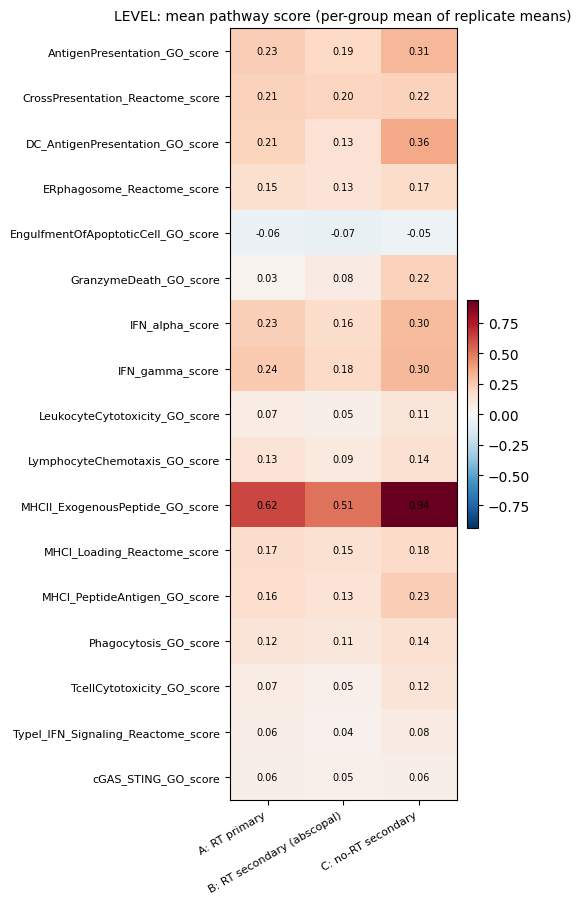

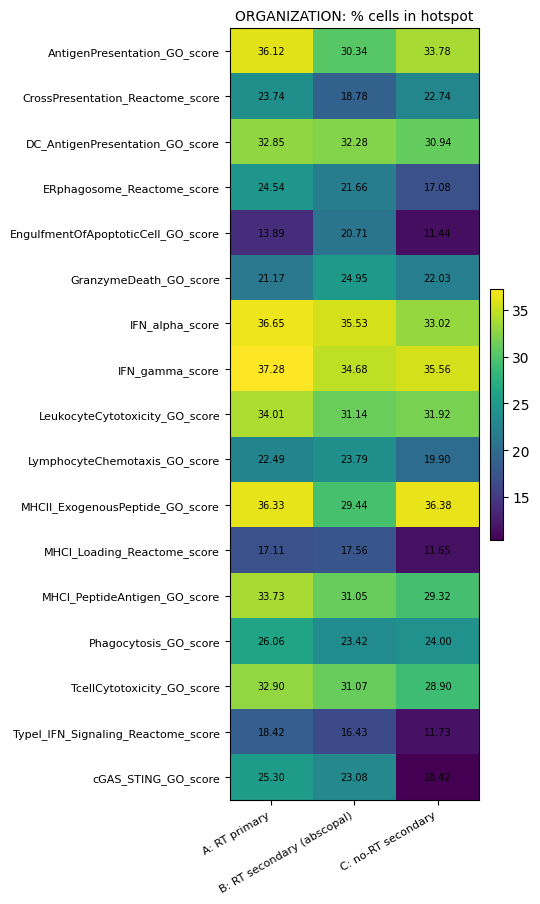

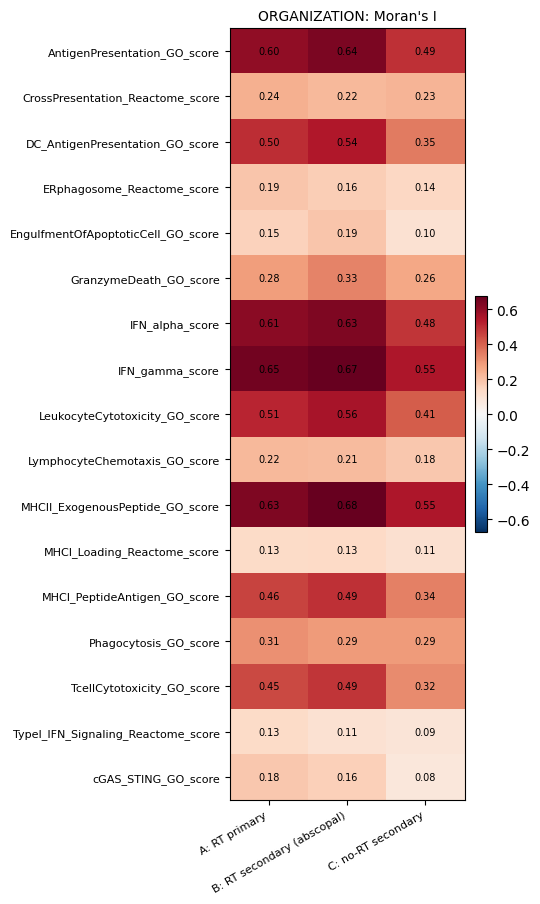

In [20]:
def group_pivot(df, value_col):
    p = (df.groupby(["pathway", "group"], observed=True)[value_col]
           .mean().unstack("group").reindex(columns=GROUP_ORDER))
    return p

def heatmap(pivot, title, fname, diverging=False, cmap=None):
    pivot = pivot.dropna(how="all")
    if pivot.empty:
        print("nothing to plot for", title); return
    data = pivot.values.astype(float)
    fig, ax = plt.subplots(figsize=(1.6 + 1.3*pivot.shape[1], 0.45*pivot.shape[0] + 1.5))
    if diverging:
        vmax = np.nanmax(np.abs(data)); vmax = vmax if vmax > 0 else 1.0
        norm = TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
        im = ax.imshow(data, cmap=cmap or "RdBu_r", norm=norm, aspect="auto")
    else:
        im = ax.imshow(data, cmap=cmap or "viridis", aspect="auto")
    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels([GROUP_LABELS.get(g, g) for g in pivot.columns], rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels(pivot.index, fontsize=8)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = data[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="black")
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(fig_dir / fname, dpi=150, bbox_inches="tight")
    plt.show()

heatmap(group_pivot(metrics_long, "mean_score"),
        "LEVEL: mean pathway score (per-group mean of replicate means)",
        "q1_level_mean_score.png", diverging=True)
heatmap(group_pivot(metrics_long, "pct_hotspot"),
        "ORGANIZATION: % cells in hotspot", "q1_org_pct_hotspot.png")
heatmap(group_pivot(metrics_long, "moranI"),
        "ORGANIZATION: Moran's I", "q1_org_moranI.png", diverging=True)

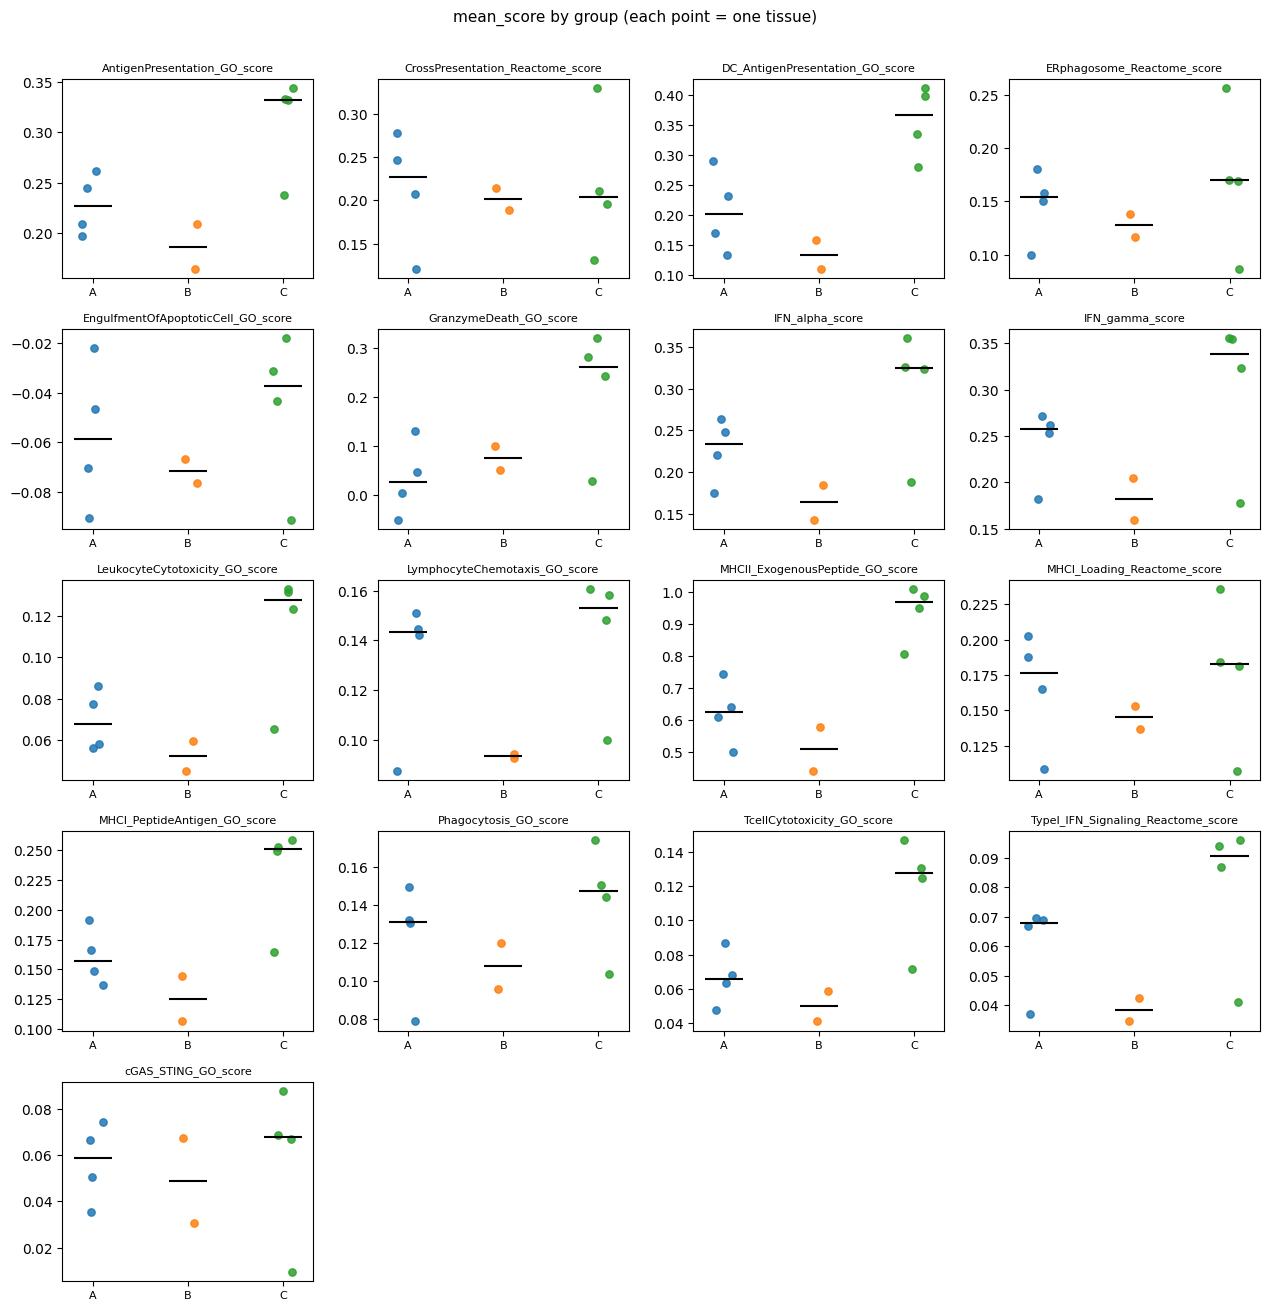

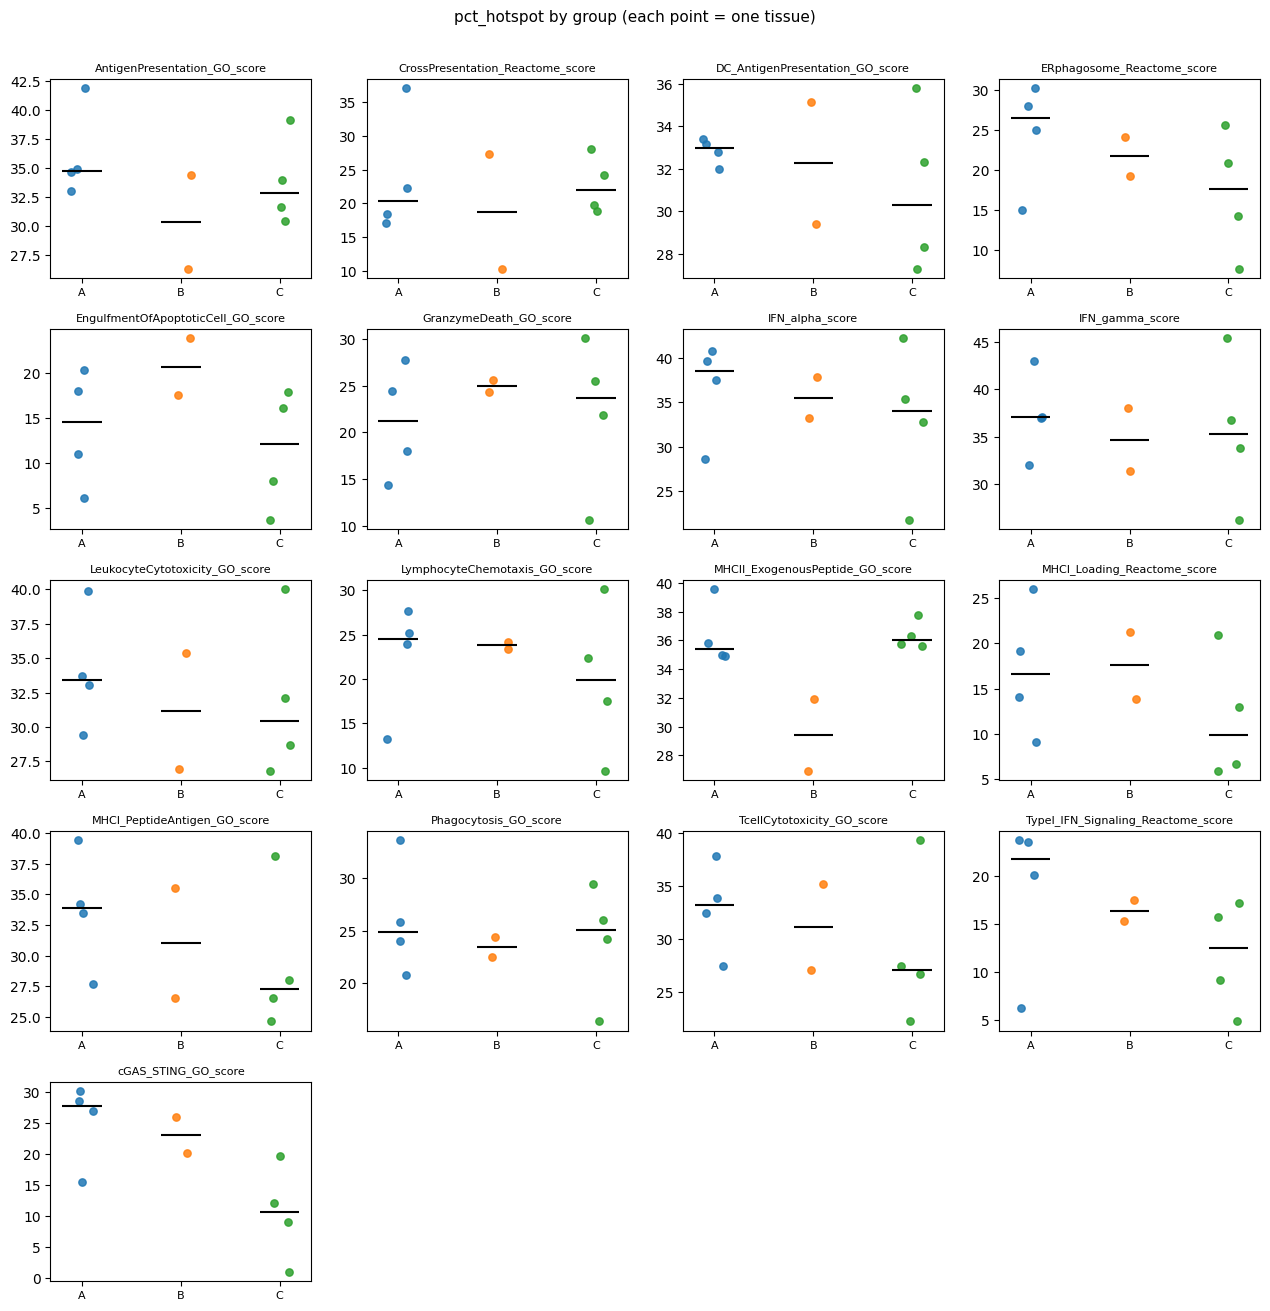

In [21]:
# Per-replicate strip plots so n is always visible.
def strip_by_group(df, value_col, fname, ncols=4):
    paths = sorted(df["pathway"].unique())
    nrows = int(np.ceil(len(paths) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.6*nrows), squeeze=False)
    xmap = {g: i for i, g in enumerate(GROUP_ORDER)}
    rng = np.random.default_rng(0)
    for ax, pth in zip(axes.ravel(), paths):
        sub = df[df["pathway"] == pth]
        for g in GROUP_ORDER:
            vals = sub.loc[sub["group"] == g, value_col].dropna().values
            x = xmap[g] + rng.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(x, vals, s=28, alpha=0.85)
            if len(vals):
                ax.hlines(np.median(vals), xmap[g]-0.2, xmap[g]+0.2, color="k", lw=1.5)
        ax.set_title(pth, fontsize=8)
        ax.set_xticks(list(xmap.values()))
        ax.set_xticklabels(["A", "B", "C"], fontsize=8)
    for ax in axes.ravel()[len(paths):]:
        ax.axis("off")
    fig.suptitle(f"{value_col} by group (each point = one tissue)", y=1.005, fontsize=11)
    fig.tight_layout()
    fig.savefig(fig_dir / fname, dpi=150, bbox_inches="tight")
    plt.show()

strip_by_group(metrics_long, "mean_score", "q1_strip_mean_score.png")
strip_by_group(metrics_long, "pct_hotspot", "q1_strip_pct_hotspot.png")

## 9. Q2 / Q2a — CD8 & NK enrichment near pathway hotspots

For each tissue x pathway, `hotspot_celltype_enrichment` computes a **density-normalized**
log2 enrichment of CD8 / NK in the zone within `ENRICH_RADIUS_UM` of a pathway hotspot,
versus a label-permutation null. Because it is normalized to each tissue's own composition,
the enrichment is comparable across A / B / C.

In [27]:
available_cts = set(adata.obs[CELL_TYPE_COL].astype(str))
celltypes = [c for c in CELLTYPES_OF_INTEREST if c in available_cts]
print("cell types used:", celltypes)

enrich_rows = []
for tissue_name in TISSUES_PRESENT:
    tissue_mask, coords_um, scale = coords_um_for(tissue_name)
    if tissue_mask.sum() < MIN_CELLS:
        continue
    obs = adata.obs.loc[tissue_mask]
    grp = tissue_to_group[tissue_name]
    ct_labels = obs[CELL_TYPE_COL].astype(str).values
    print(f"{tissue_name} | {grp}")
    for sc_col in score_cols:
        hot_col = f"{sc_col}_hotspot"
        if hot_col not in obs.columns:
            continue
        hot = obs[hot_col].astype(bool).values
        if hot.sum() == 0:
            continue
        for ct in celltypes:
            ct_mask = (ct_labels == ct)
            res = gu.hotspot_celltype_enrichment(
                coords_um, hot, ct_mask,
                radius_um=ENRICH_RADIUS_UM, n_perm=N_PERM, rng=0)
            enrich_rows.append({
                "tissue": tissue_name, "group": grp, "pathway": sc_col, "celltype": ct,
                "n_hotspot": res["n_hotspot"], "n_near": res["n_near"],
                "n_celltype": res["n_celltype"],
                "obs_frac": res["obs_frac"], "baseline_frac": res["baseline_frac"],
                "log2_enrich": res["log2_enrich"], "z": res["z"], "emp_p": res["emp_p"],
            })

enrich_long = pd.DataFrame(enrich_rows)
enrich_long["group"] = pd.Categorical(enrich_long["group"], categories=GROUP_ORDER, ordered=True)
# clip infinite log2 (obs_frac==0) for display/aggregation
enrich_long["log2_enrich"] = enrich_long["log2_enrich"].replace([np.inf, -np.inf], np.nan)
print("enrich_long:", enrich_long.shape)
display(enrich_long.head(12))

cell types used: ['CD8_T', 'NK']
RTCyPSCA_1_2 | A_RT_primary
RTCyPSCA_1_3 | A_RT_primary
RTCyPSCA_1_4 | A_RT_primary
RTCyPSCA_1_5 | A_RT_primary
RTCyPSCA_2_3 | B_RT_secondary
RTCyPSCA_2_4 | B_RT_secondary
CyPSCA_2_1 | C_noRT_secondary
CyPSCA_2_2 | C_noRT_secondary
CyPSCA_2_3 | C_noRT_secondary
CyPSCA_2_4 | C_noRT_secondary
enrich_long: (340, 12)


,tissue,group,pathway,celltype,n_hotspot,n_near,n_celltype,obs_frac,baseline_frac,log2_enrich,z,emp_p
0,RTCyPSCA_1_2,A_RT_primary,GranzymeDeath_GO_score,CD8_T,7965,21570,130,0.004172,0.004540,-0.121661,-1.605423,0.127872
1,RTCyPSCA_1_2,A_RT_primary,GranzymeDeath_GO_score,NK,7965,21570,34,0.001020,0.001187,-0.219177,-1.389391,0.179820
2,RTCyPSCA_1_2,A_RT_primary,Phagocytosis_GO_score,CD8_T,9646,23656,130,0.004523,0.004540,-0.005227,-0.085988,1.000000
3,RTCyPSCA_1_2,A_RT_primary,Phagocytosis_GO_score,NK,9646,23656,34,0.001310,0.001187,0.142408,1.258525,0.271728
4,RTCyPSCA_1_2,A_RT_primary,EngulfmentOfApoptoticCell_GO_score,CD8_T,5829,19249,130,0.004104,0.004540,-0.145490,-1.559692,0.131868
5,RTCyPSCA_1_2,A_RT_primary,EngulfmentOfApoptoticCell_GO_score,NK,5829,19249,34,0.000987,0.001187,-0.266438,-1.409677,0.218781
6,RTCyPSCA_1_2,A_RT_primary,AntigenPresentation_GO_score,CD8_T,12001,22583,130,0.004340,0.004540,-0.065015,-0.978500,0.343656
7,RTCyPSCA_1_2,A_RT_primary,AntigenPresentation_GO_score,NK,12001,22583,34,0.001328,0.001187,0.162071,1.276854,0.229770
8,RTCyPSCA_1_2,A_RT_primary,MHCII_ExogenousPeptide_GO_score,CD8_T,11333,22623,130,0.004111,0.004540,-0.143119,-2.012065,0.044955
9,RTCyPSCA_1_2,A_RT_primary,MHCII_ExogenousPeptide_GO_score,NK,11333,22623,34,0.001282,0.001187,0.110608,0.853418,0.435564


In [24]:
# Group comparison of enrichment (same replicate-level scheme as Q1), per pathway x celltype
q2_parts = []
for ct in celltypes:
    sub = enrich_long[enrich_long["celltype"] == ct]
    part = contrast_rows(sub, "log2_enrich", ["pathway"])
    part.insert(0, "celltype", ct)
    q2_parts.append(part)
group_contrasts_q2 = pd.concat(q2_parts, ignore_index=True) if q2_parts else pd.DataFrame()
if not group_contrasts_q2.empty:
    display(group_contrasts_q2.sort_values(["celltype", "pathway"]).round(3))

,celltype,pathway,A_vs_B__median_diff,A_vs_B__cliffs_delta,A_vs_B__mwu_p,B_vs_C__median_diff,B_vs_C__cliffs_delta,B_vs_C__mwu_p
0,CD8_T,AntigenPresentation_GO_score,-0.042,0.00,1.000,0.010,0.000,1.000
1,CD8_T,CrossPresentation_Reactome_score,-0.200,-0.50,0.533,0.233,0.750,0.267
2,CD8_T,DC_AntigenPresentation_GO_score,-0.036,0.00,1.000,-0.060,-0.250,0.800
3,CD8_T,ERphagosome_Reactome_score,-0.004,0.00,1.000,0.138,0.250,0.800
4,CD8_T,EngulfmentOfApoptoticCell_GO_score,-0.069,-0.75,0.267,0.086,0.250,0.800
5,CD8_T,GranzymeDeath_GO_score,-0.109,-0.25,0.800,0.100,0.750,0.267
6,CD8_T,IFN_alpha_score,-0.159,-0.75,0.267,0.130,0.750,0.267
7,CD8_T,IFN_gamma_score,-0.138,-0.75,0.267,0.153,0.500,0.533
8,CD8_T,LeukocyteCytotoxicity_GO_score,-0.105,-0.25,0.800,0.120,0.500,0.533
9,CD8_T,LymphocyteChemotaxis_GO_score,-0.056,0.00,1.000,0.003,0.000,1.000


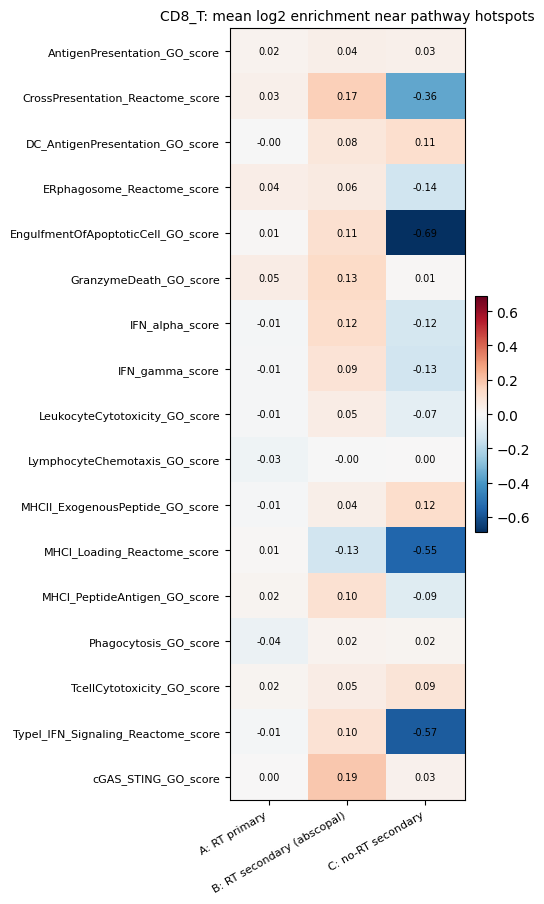

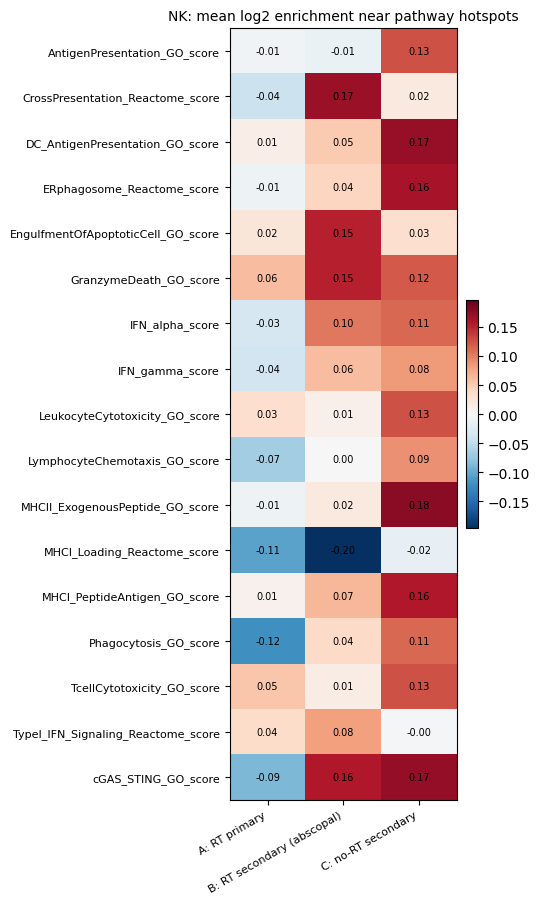

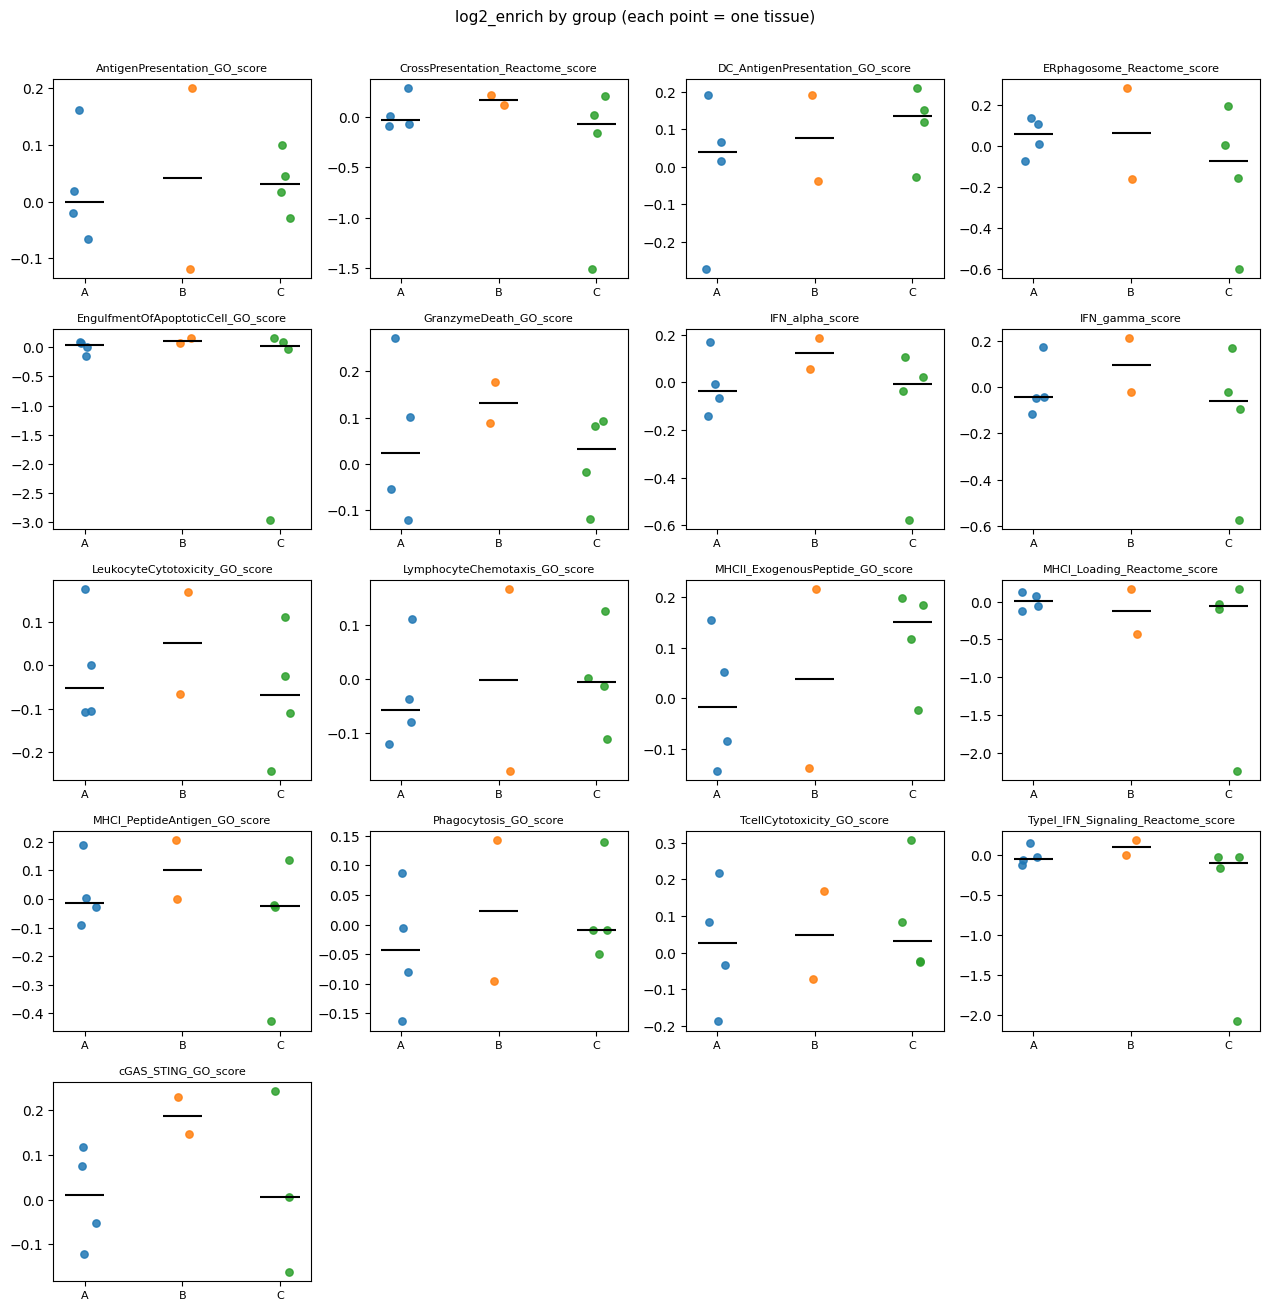

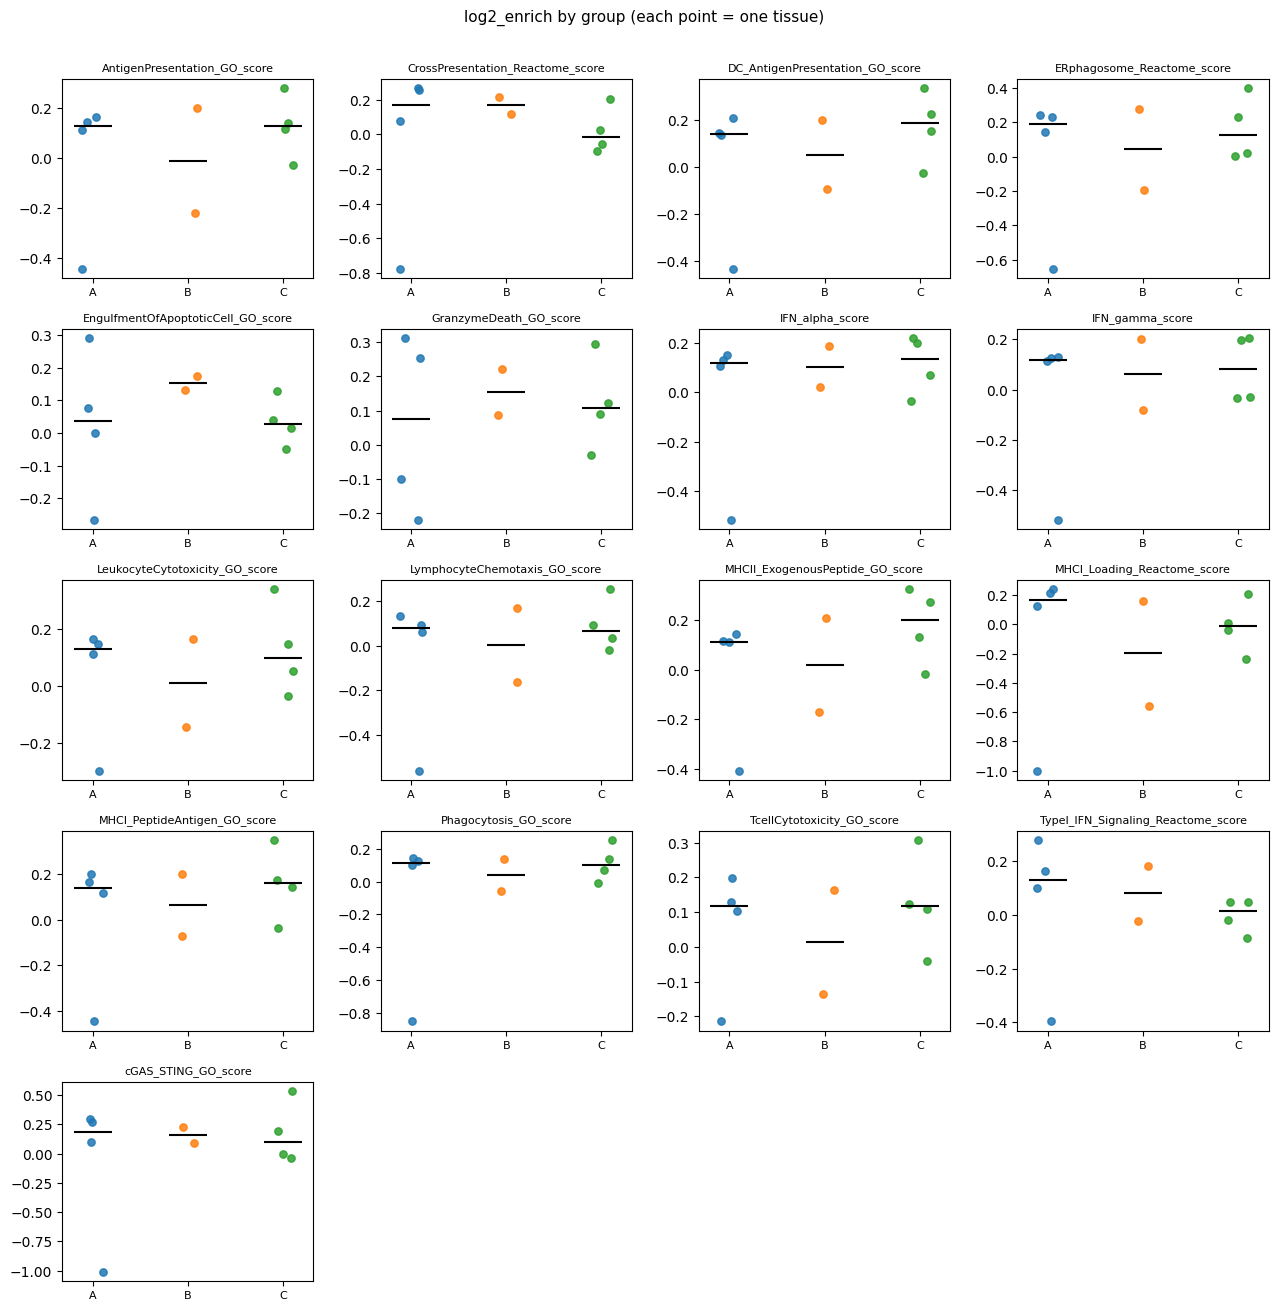

In [25]:
# Heatmaps: pathway x group mean log2 enrichment, one per cell type.
for ct in celltypes:
    sub = enrich_long[enrich_long["celltype"] == ct]
    piv = (sub.groupby(["pathway", "group"], observed=True)["log2_enrich"]
              .mean().unstack("group").reindex(columns=GROUP_ORDER))
    heatmap(piv, f"{ct}: mean log2 enrichment near pathway hotspots",
            f"q2_{ct}_log2_enrich.png", diverging=True)

# Per-replicate strip plots of enrichment.
for ct in celltypes:
    strip_by_group(enrich_long[enrich_long["celltype"] == ct],
                   "log2_enrich", f"q2_{ct}_strip_log2_enrich.png")

In [26]:
# Highlight: pathways where B (abscopal) shows higher CD8/NK enrichment than BOTH A and C.
if not enrich_long.empty:
    mean_by = (enrich_long.groupby(["celltype", "pathway", "group"], observed=True)["log2_enrich"]
                          .mean().unstack("group").reindex(columns=GROUP_ORDER))
    highlight = mean_by[(mean_by["B_RT_secondary"] > mean_by["A_RT_primary"]) &
                        (mean_by["B_RT_secondary"] > mean_by["C_noRT_secondary"])]
    print("Pathways where CD8/NK enrichment is highest in B (abscopal):")
    display(highlight.round(3))

Pathways where CD8/NK enrichment is highest in B (abscopal):


group                                        A_RT_primary  B_RT_secondary  C_noRT_secondary
celltype pathway                                                                           
CD8_T    AntigenPresentation_GO_score               0.024           0.041             0.034
         CrossPresentation_Reactome_score           0.032           0.166            -0.359
         ERphagosome_Reactome_score                 0.045           0.062            -0.139
         EngulfmentOfApoptoticCell_GO_score         0.008           0.112            -0.689
         GranzymeDeath_GO_score                     0.049           0.133             0.009
         IFN_alpha_score                           -0.011           0.122            -0.122
         IFN_gamma_score                           -0.009           0.093            -0.131
         LeukocyteCytotoxicity_GO_score            -0.009           0.053            -0.067
         MHCI_PeptideAntigen_GO_score               0.018           0.103            -0.086
         Phagocytosis_GO_score                     -0.040           0.024             0.018
         TypeI_IFN_Signaling_Reactome_score        -0.013           0.099            -0.571
         cGAS_STING_GO_score                        0.005           0.188             0.029
NK       CrossPresentation_Reactome_score          -0.042           0.170             0.020
         EngulfmentOfApoptoticCell_GO_score         0.024           0.153             0.033
         GranzymeDeath_GO_score                     0.061           0.153             0.120
         TypeI_IFN_Signaling_Reactome_score         0.035           0.080            -0.003

## 9b. Focused abscopal-axis figures

The story in one panel: CD8 localization (log2 enrichment near hotspots) along the
mechanistic chain **cGAS-STING → type I IFN → cross-presentation → MHC-I → granzyme
killing**, for groups A/B/C. Each dot is one tissue; the vertical tick is the group
mean; the dashed line is no enrichment. `d(B,C)` is the Cliff's delta for the
abscopal-vs-control contrast.

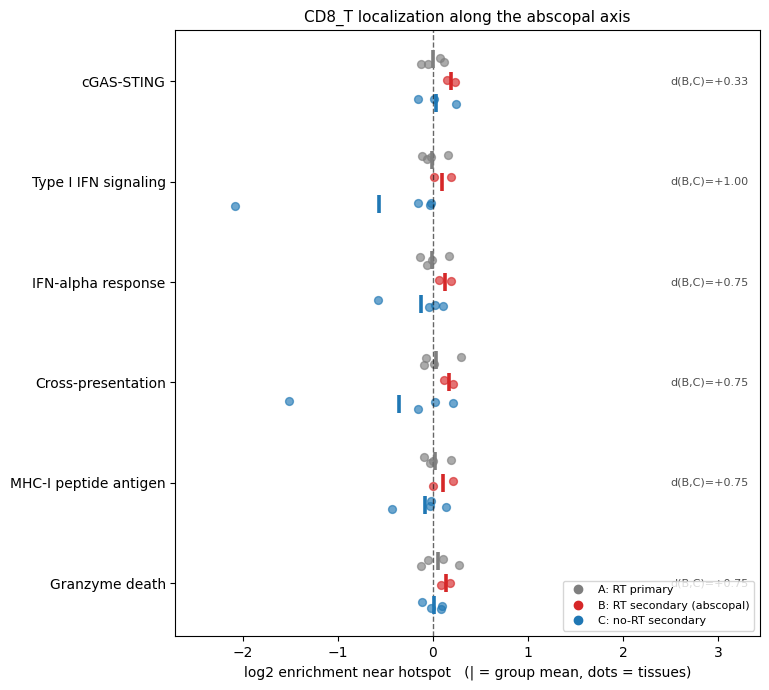

In [28]:
# Focused figure: CD8 localization along the abscopal axis
# (cGAS-STING -> type I IFN -> cross-presentation -> MHC-I -> granzyme killing)
AXIS_PATHWAYS = [
    "cGAS_STING_GO_score",
    "TypeI_IFN_Signaling_Reactome_score",
    "IFN_alpha_score",
    "CrossPresentation_Reactome_score",
    "MHCI_PeptideAntigen_GO_score",
    "GranzymeDeath_GO_score",
]
AXIS_LABELS = {
    "cGAS_STING_GO_score": "cGAS-STING",
    "TypeI_IFN_Signaling_Reactome_score": "Type I IFN signaling",
    "IFN_alpha_score": "IFN-alpha response",
    "CrossPresentation_Reactome_score": "Cross-presentation",
    "MHCI_PeptideAntigen_GO_score": "MHC-I peptide antigen",
    "GranzymeDeath_GO_score": "Granzyme death",
}
GROUP_COLORS = {"A_RT_primary": "#7f7f7f", "B_RT_secondary": "#d62728", "C_noRT_secondary": "#1f77b4"}

def plot_axis_enrichment(celltype="CD8_T"):
    sub = enrich_long[enrich_long["celltype"] == celltype]
    paths = [p for p in AXIS_PATHWAYS if p in set(sub["pathway"])]
    if not paths:
        print(f"No axis pathways present for {celltype}")
        return
    axis_vals = sub.loc[sub["pathway"].isin(paths), "log2_enrich"].dropna()
    xmax = float(np.nanmax(np.abs(axis_vals))) if len(axis_vals) else 0.5
    xmax = xmax if xmax > 0 else 0.5
    yb = np.arange(len(paths))[::-1]
    offsets = {"A_RT_primary": 0.22, "B_RT_secondary": 0.0, "C_noRT_secondary": -0.22}
    rng = np.random.default_rng(0)
    fig, ax = plt.subplots(figsize=(7.8, 0.95 * len(paths) + 1.3))
    for g in GROUP_ORDER:
        for yi, p in zip(yb, paths):
            vals = sub.loc[(sub["pathway"] == p) & (sub["group"] == g), "log2_enrich"].dropna().values
            y = yi + offsets[g]
            ax.scatter(vals, y + rng.uniform(-0.05, 0.05, size=len(vals)),
                       s=32, color=GROUP_COLORS[g], alpha=0.65, zorder=2)
            if len(vals):
                ax.scatter(np.mean(vals), y, s=160, marker="|", linewidths=2.6,
                           color=GROUP_COLORS[g], zorder=3)
    for yi, p in zip(yb, paths):
        b = sub.loc[(sub["pathway"] == p) & (sub["group"] == "B_RT_secondary"), "log2_enrich"].values
        c = sub.loc[(sub["pathway"] == p) & (sub["group"] == "C_noRT_secondary"), "log2_enrich"].values
        ax.text(xmax * 1.20, yi, f"d(B,C)={gu.cliffs_delta(b, c):+.2f}", va="center",
                fontsize=8, color="0.3")
    ax.axvline(0, color="k", lw=1, ls="--", alpha=0.6)
    ax.set_yticks(yb)
    ax.set_yticklabels([AXIS_LABELS.get(p, p) for p in paths], fontsize=10)
    ax.set_xlabel("log2 enrichment near hotspot   (| = group mean, dots = tissues)")
    ax.set_xlim(-xmax * 1.30, xmax * 1.65)
    ax.set_title(f"{celltype} localization along the abscopal axis", fontsize=11)
    handles = [plt.Line2D([0], [0], marker="o", ls="", color=GROUP_COLORS[g],
                          label=GROUP_LABELS[g]) for g in GROUP_ORDER]
    ax.legend(handles=handles, fontsize=8, loc="lower right", frameon=True)
    fig.tight_layout()
    fig.savefig(fig_dir / f"axis_{celltype}_enrichment.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_axis_enrichment("CD8_T")
# plot_axis_enrichment("NK")   # uncomment for the NK version


### Which cell types carry the cGAS-STING / cross-presentation hotspots?

Addresses *which* cells are sensing: the table shows the cell-type composition
**inside** each hotspot, and the heatmaps show which cell types are
**over-represented** there relative to the whole tissue (log2 vs baseline). Watch
cDC / macrophages (professional cross-presenters / DNA sensors) vs tumor cells.

group                                               A_RT_primary  B_RT_secondary  C_noRT_secondary
pathway                          cell_type                                                        
CrossPresentation_Reactome_score B                          1.75            2.62              0.95
                                 CD4_T                      0.17            0.52              0.20
                                 CD8_T                      0.49            2.78              7.00
                                 Cancer_cell                9.97           18.69              4.02
                                 Classical_Mono            10.03            7.85             11.18
                                 Endothelial                0.31            0.47              0.23
                                 Erythrocyte               16.60           17.54             14.22
                                 Fibroblast                 0.23            0.15              0.05
                                 Intermediate_Mac           0.02            0.22              0.07
                                 M1_like_Mac                1.52            3.38              2.97
                                 M2_like_Mac                2.52            2.33              2.64
                                 N1_like_Neu               20.01           14.29             15.52
                                 N2_like_Neu                9.03            5.10              3.51
                                 NK                         0.09            1.18              1.41
                                 NKT                        0.14            0.27              0.17
                                 Nonclassical_Mono          0.11            0.25              0.32
                                 Treg                       0.44            0.52              0.26
                                 Unknown                   26.31           21.36             34.88
                                 cDC                        0.18            0.23              0.26
                                 pDC                        0.08            0.26              0.14
cGAS_STING_GO_score              B                          1.02            1.72              0.91
                                 CD4_T                      0.07            0.36              0.18
                                 CD8_T                      0.33            2.50              6.84
                                 Cancer_cell                4.68           11.72              2.95
                                 Classical_Mono            14.35           10.20             16.95
                                 Endothelial                0.29            0.39              0.25
                                 Erythrocyte               12.72           13.91             12.38
                                 Fibroblast                 0.21            0.19              0.05
                                 Intermediate_Mac           0.00            0.09              0.04
                                 M1_like_Mac                1.28            3.07              1.62
                                 M2_like_Mac                1.47            1.13              1.25
                                 N1_like_Neu               20.27           15.80             16.47
                                 N2_like_Neu                5.24            3.93              1.92
                                 NK                         0.11            0.85              1.24
                                 NKT                        0.07            0.30              0.22
                                 Nonclassical_Mono          0.16            0.27              0.26
                                 Treg                       0.27            0.45              0.14
                                 Unknown                   37.28           32.72             36.08
                                 cDC    

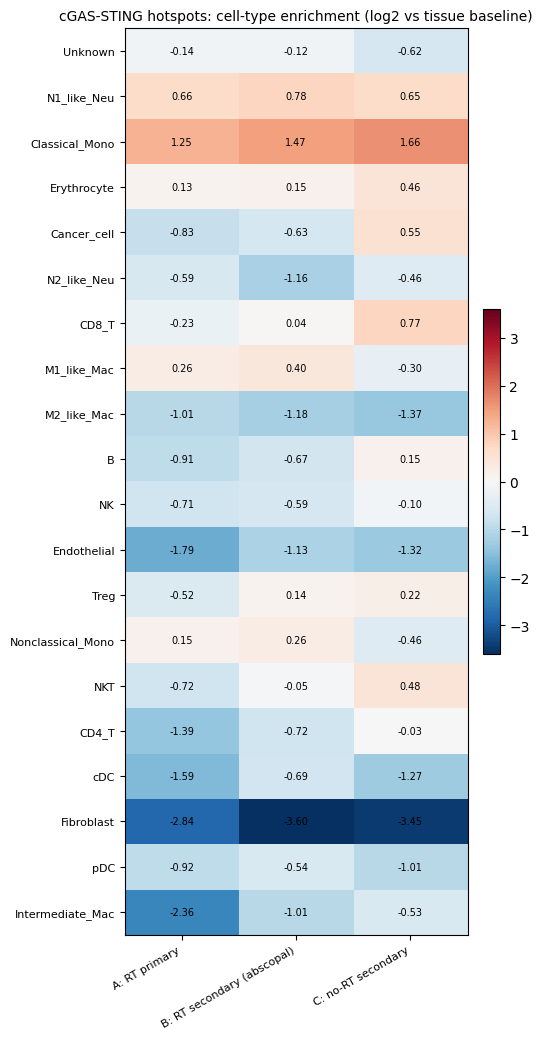

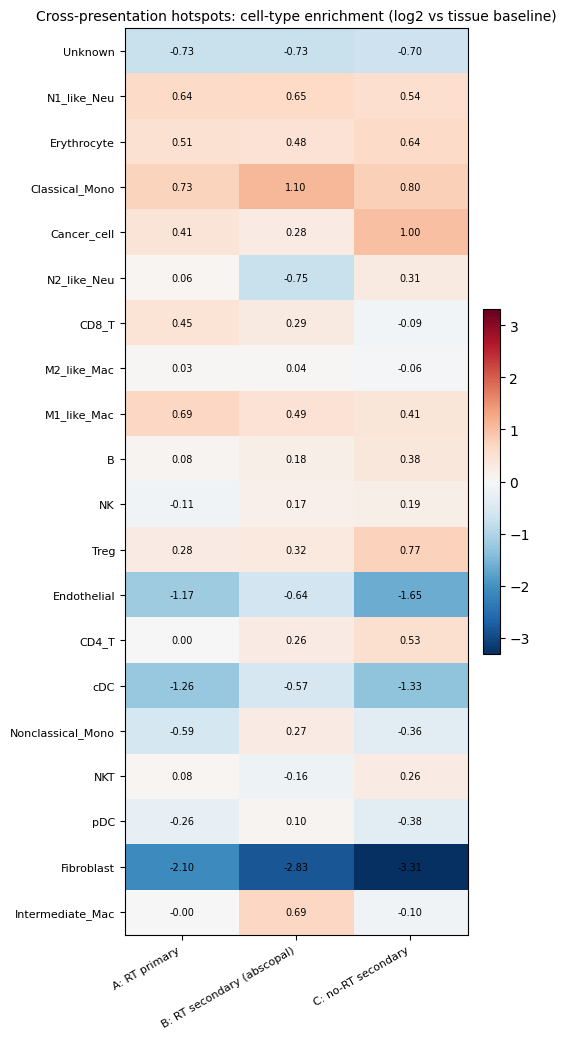

In [29]:
# Which cell types make up (and are enriched in) the cGAS-STING / cross-presentation hotspots?
FOCUS_PATHWAYS = [p for p in ["cGAS_STING_GO_score", "CrossPresentation_Reactome_score"] if p in score_cols]

comp_rows = []
for tissue_name in TISSUES_PRESENT:
    tissue_mask = adata.obs[TISSUE_COL].astype(str).eq(tissue_name).values
    obs = adata.obs.loc[tissue_mask]
    if len(obs) < MIN_CELLS:
        continue
    grp = tissue_to_group[tissue_name]
    ct_all = obs[CELL_TYPE_COL].astype(str)
    base = ct_all.value_counts(normalize=True)
    for p in FOCUS_PATHWAYS:
        hot_col = f"{p}_hotspot"
        if hot_col not in obs.columns:
            continue
        hot = obs[hot_col].astype(bool).values
        if hot.sum() == 0:
            continue
        comp = ct_all[hot].value_counts(normalize=True)
        for ct in base.index:
            ph = float(comp.get(ct, 0.0))
            pb = float(base.get(ct, 0.0))
            comp_rows.append({
                "tissue": tissue_name, "group": grp, "pathway": p, "cell_type": ct,
                "pct_in_hotspot": ph * 100.0, "pct_in_tissue": pb * 100.0,
                "log2_enrich": float(np.log2(ph / pb)) if (ph > 0 and pb > 0) else np.nan,
            })

hotspot_composition_focus = pd.DataFrame(comp_rows)
hotspot_composition_focus["group"] = pd.Categorical(
    hotspot_composition_focus["group"], categories=GROUP_ORDER, ordered=True)

# Mean % composition within hotspots, per group
display(
    hotspot_composition_focus
    .groupby(["pathway", "cell_type", "group"], observed=True)["pct_in_hotspot"]
    .mean().round(2).unstack("group").reindex(columns=GROUP_ORDER)
)

# Heatmap: which cell types are OVER-represented inside each focus hotspot (vs tissue baseline)
for p in FOCUS_PATHWAYS:
    dfp = hotspot_composition_focus[hotspot_composition_focus["pathway"] == p]
    piv = (dfp.groupby(["cell_type", "group"], observed=True)["log2_enrich"]
              .mean().unstack("group").reindex(columns=GROUP_ORDER))
    order = (dfp.groupby("cell_type")["pct_in_hotspot"].mean()
                .sort_values(ascending=False).index)
    piv = piv.reindex(order)
    heatmap(piv,
            f"{AXIS_LABELS.get(p, p)} hotspots: cell-type enrichment (log2 vs tissue baseline)",
            f"hotspot_celltype_enrich_{p}.png", diverging=True)


### Spatial overlay — CD8 vs hotspots, abscopal (B) vs no-RT (C)

CD8 T cells (black) over the pathway hotspots (red) in the most-illustrative B tumor
(strongest CD8 enrichment) vs C tumor (weakest). Visual check of the co-localization
(B) vs exclusion (C) contrast; per-panel annotation gives the density-normalized
enrichment + permutation p.

Overlay tumors -> B: RTCyPSCA_2_4 | C: CyPSCA_2_3


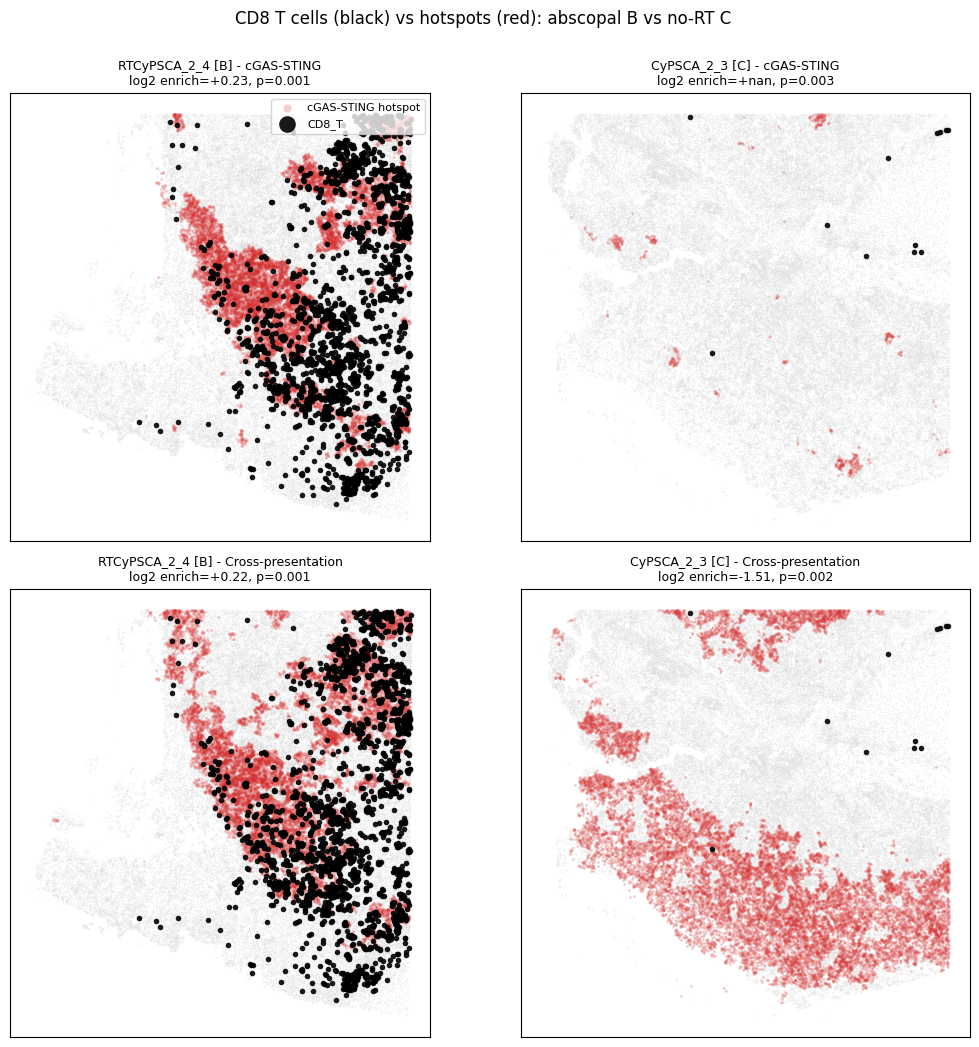

In [30]:
# Spatial overlay: CD8 cells vs pathway hotspots, abscopal (B) vs no-RT secondary (C)
OVERLAY_PATHWAYS = [p for p in ["cGAS_STING_GO_score", "CrossPresentation_Reactome_score"] if p in score_cols]
OVERLAY_CT = "CD8_T"

def _mean_axis_enrich(tissue_name):
    s = enrich_long[(enrich_long["tissue"] == tissue_name)
                    & (enrich_long["celltype"] == OVERLAY_CT)
                    & (enrich_long["pathway"].isin(OVERLAY_PATHWAYS))]["log2_enrich"]
    return s.mean()

B_tissues = [t for t in TISSUES_PRESENT if tissue_to_group[t] == "B_RT_secondary"]
C_tissues = [t for t in TISSUES_PRESENT if tissue_to_group[t] == "C_noRT_secondary"]
# most illustrative pair: B tumor with strongest CD8 enrichment, C tumor with weakest (exclusion)
B_tissue = max(B_tissues, key=_mean_axis_enrich) if B_tissues else None
C_tissue = min(C_tissues, key=_mean_axis_enrich) if C_tissues else None
print("Overlay tumors -> B:", B_tissue, "| C:", C_tissue)

def _overlay(ax, tissue_name, score_col):
    tissue_mask, coords_um, _ = coords_um_for(tissue_name)
    obs = adata.obs.loc[tissue_mask]
    hot = obs[f"{score_col}_hotspot"].astype(bool).values
    ct_mask = obs[CELL_TYPE_COL].astype(str).eq(OVERLAY_CT).values
    ax.scatter(coords_um[:, 0], coords_um[:, 1], s=1.0, c="lightgray", alpha=0.30,
               linewidths=0, rasterized=True)
    ax.scatter(coords_um[hot, 0], coords_um[hot, 1], s=4, c="#d62728", alpha=0.22,
               linewidths=0, rasterized=True, label=f"{AXIS_LABELS.get(score_col, score_col)} hotspot")
    ax.scatter(coords_um[ct_mask, 0], coords_um[ct_mask, 1], s=16, c="black", alpha=0.9,
               linewidths=0, rasterized=True, label=OVERLAY_CT)
    row = enrich_long[(enrich_long["tissue"] == tissue_name)
                      & (enrich_long["celltype"] == OVERLAY_CT)
                      & (enrich_long["pathway"] == score_col)]
    ann = f"\nlog2 enrich={row['log2_enrich'].iloc[0]:+.2f}, p={row['emp_p'].iloc[0]:.3f}" if len(row) else ""
    grp_tag = tissue_to_group[tissue_name].split("_")[0]
    ax.set_title(f"{tissue_name} [{grp_tag}] - {AXIS_LABELS.get(score_col, score_col)}{ann}", fontsize=9)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])

if B_tissue and C_tissue and OVERLAY_PATHWAYS:
    nrows = len(OVERLAY_PATHWAYS)
    fig, axes = plt.subplots(nrows, 2, figsize=(11, 5.2 * nrows), squeeze=False)
    for i, p in enumerate(OVERLAY_PATHWAYS):
        _overlay(axes[i, 0], B_tissue, p)
        _overlay(axes[i, 1], C_tissue, p)
    axes[0, 0].legend(markerscale=3, fontsize=8, loc="upper right", frameon=True)
    fig.suptitle("CD8 T cells (black) vs hotspots (red): abscopal B vs no-RT C", y=1.002, fontsize=12)
    fig.tight_layout()
    fig.savefig(fig_dir / "overlay_CD8_vs_hotspots_BvsC.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Need at least one B and one C tissue (and focus pathways) for the overlay.")


## 10. Save outputs

In [ ]:
metrics_long.to_csv(out_dir / "comparison_metrics_long.csv", index=False)
group_contrasts_q1.to_csv(out_dir / "group_contrasts_q1.csv", index=False)
score_coverage.to_csv(out_dir / "pathway_score_coverage.csv", index=False)
tissue_meta.to_csv(out_dir / "tissue_group_map.csv", index=False)
enrich_long.to_csv(out_dir / "celltype_hotspot_enrichment_long.csv", index=False)
if not group_contrasts_q2.empty:
    group_contrasts_q2.to_csv(out_dir / "group_contrasts_q2.csv", index=False)
if "hotspot_composition_focus" in globals() and not hotspot_composition_focus.empty:
    hotspot_composition_focus.to_csv(out_dir / "focus_hotspot_celltype_composition.csv", index=False)

print("Saved to:", out_dir)
for f in sorted(out_dir.glob("*.csv")):
    print("  ", f.name)
print("Figures in:", fig_dir)

## 11. How to read these outputs

- **Q1 (level vs organization).** A pathway is "up and spatially organized" in a group when
  *both* `mean_score` (level) and `pct_hotspot` / `moranI` (organization) rise together. If
  `mean_score` rises but `pct_hotspot` falls, the pathway is **uniformly** higher (less
  patchy) — still biologically real, but a different statement. Never read `pct_hotspot`
  alone as "more antigen presentation."
- **Key contrasts.** `A_vs_B` = abscopal effect within RT; `B_vs_C` = whether irradiating the
  primary reorganizes the secondary vs an unirradiated secondary. `B_vs_C` is the cleanest
  abscopal test.
- **Effect sizes over p-values.** With n=4/2/4 (and only **n=2 for B**), Mann-Whitney p-values
  cannot reach significance for many configurations. Lead with Cliff's delta + the
  per-replicate strip plots; use the mixed model as supporting evidence.
- **Q2 enrichment.** Positive `log2_enrich` = CD8/NK over-represented around that pathway's
  hotspots, normalized to tissue composition. The highlighted table flags pathways where the
  abscopal tumor (B) draws CD8/NK closer to hotspots than both the irradiated primary (A) and
  the no-RT control (C) — the spatial signature your hypothesis predicts.
- **Add more B replicates** if available (only 2 here) — it is the single biggest lever on
  statistical confidence.